<a href="https://colab.research.google.com/github/felwern/AI_course_exercises/blob/main/Project_Line_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJECT PUBLIC TRANSPORTATION**

# imports and setup

In this section, we import the libraries required for data loading, preprocessing, analysis, visualization and machine learning. We also define the project path and basic settings used throughout the analysis.

In [81]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    RidgeCV,
    LassoCV
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

In [3]:
drive.mount('/content/drive')

project_path = "/content/drive/MyDrive/fellie2026/AI/project"

print(os.listdir(project_path)) #dubble checking that the file exists

Mounted at /content/drive
['transfers.csv', 'trips.csv', 'gtfs_rt_202406.csv.gz', 'service_alerts_2024.parquet', 'gtfs_rt_202407.csv.gz', 'stops.csv', 'routes.csv', 'gtfs_rt_202401.csv.gz', 'gtfs_rt_202405.csv.gz', 'gtfs_rt_202404.csv.gz', 'gtfs_rt_202403.csv.gz', 'gtfs_rt_202402.csv.gz', 'gtfs_rt_202408.csv.gz', 'gtfs_rt_202409.csv.gz', 'gtfs_rt_202410.csv.gz', 'gtfs_rt_202411.csv.gz', 'gtfs_rt_202412.csv.gz', 'tram30_weekday_morning_2024.csv', 'bus4_january_weekday_07_09_2024.csv', 'line4_weekday_07_09_2024.csv', 'line4_BUS_all_days_2024.csv', 'torkel_2024.xlsx', 'torkel_2024_filtrerad.csv']


In [4]:
for file in os.listdir(project_path):
    full_path = os.path.join(project_path, file)

    if os.path.isfile(full_path):
        size_mb = os.path.getsize(full_path) / (1024**2)
        print(f"{file:70s} {size_mb:.2f} MB")

transfers.csv                                                          2.83 MB
trips.csv                                                              17.10 MB
gtfs_rt_202406.csv.gz                                                  301.71 MB
service_alerts_2024.parquet                                            27.69 MB
gtfs_rt_202407.csv.gz                                                  299.63 MB
stops.csv                                                              1.35 MB
routes.csv                                                             0.02 MB
gtfs_rt_202401.csv.gz                                                  327.68 MB
gtfs_rt_202405.csv.gz                                                  327.63 MB
gtfs_rt_202404.csv.gz                                                  318.96 MB
gtfs_rt_202403.csv.gz                                                  325.08 MB
gtfs_rt_202402.csv.gz                                                  306.33 MB
gtfs_rt_202408.csv.gz               

#Understanding the data

## Dataset overview

The first step is to understand the available data before defining the modelling dataset. We inspect the different datasets, their dimensions, variables and data types to identify which information can be used for the analysis.

In [ ]:
jan_path = os.path.join(
    project_path,
    "gtfs_rt_202401.csv.gz"
)

df_sample = pd.read_csv(
    jan_path,
    sep=";",
    nrows=10000
)

print("Shape:", df_sample.shape)

display(df_sample.head())

Shape: (10000, 28)


,date,LineNumber,LineID,route_id,TransportMode,direction_id,trip_id,VehicleID,shape_id,planned_departure_sfm,...,observed_arrival_time_sfm,observed_arrival_delay,observed_arrival_uncertainty,scheduled_departure_time_sfm,observed_departure_time_sfm,observed_departure_delay,observed_departure_uncertainty,tripupdates_and_gtfs_not_merged_within_service_id,tripupdates_not_merged_with_stoptimes_or_trip,stop_headsign
0,20240101,1,9011001000100000,9011001000100000,BUS,0,14010000635988873,9.031001e+15,1014010000560262054,420,...,360.0,-60.0,0.0,420,498.0,78.0,0.0,f,f,Frihamnen
1,20240101,1,9011001000100000,9011001000100000,BUS,0,14010000635988873,9.031001e+15,1014010000560262054,420,...,540.0,80.0,0.0,460,540.0,80.0,0.0,f,f,Frihamnen
2,20240101,1,9011001000100000,9011001000100000,BUS,0,14010000635988873,9.031001e+15,1014010000560262054,420,...,578.0,84.0,0.0,494,578.0,84.0,0.0,f,f,Frihamnen
3,20240101,1,9011001000100000,9011001000100000,BUS,0,14010000635988873,9.031001e+15,1014010000560262054,420,...,660.0,60.0,0.0,600,660.0,60.0,0.0,f,f,Frihamnen
4,20240101,1,9011001000100000,9011001000100000,BUS,0,14010000635988873,9.031001e+15,1014010000560262054,420,...,711.0,49.0,0.0,662,740.0,78.0,0.0,f,f,Frihamnen


In [ ]:
display(df_sample.dtypes)

,0
date,int64
LineNumber,int64
LineID,int64
route_id,int64
TransportMode,object
direction_id,int64
trip_id,int64
VehicleID,float64
shape_id,int64
planned_departure_sfm,int64


In [ ]:
print("Number of rows:", len(df_sample))
print("Number of columns:", len(df_sample.columns))

print("\nColumns:")
for i, col in enumerate(df_sample.columns):
    print(f"{i}: {col}")

display(df_sample.head())

Number of rows: 10000
Number of columns: 28

Columns:
0: date
1: LineNumber
2: LineID
3: route_id
4: TransportMode
5: direction_id
6: trip_id
7: VehicleID
8: shape_id
9: planned_departure_sfm
10: planned_departure_tripupdates_sfm
11: stop_sequence
12: dist_traveled
13: previous_stop_id
14: previous_StopAreaID
15: observed_stop_id
16: observed_StopAreaID
17: scheduled_arrival_time_sfm
18: observed_arrival_time_sfm
19: observed_arrival_delay
20: observed_arrival_uncertainty
21: scheduled_departure_time_sfm
22: observed_departure_time_sfm
23: observed_departure_delay
24: observed_departure_uncertainty
25: tripupdates_and_gtfs_not_merged_within_service_id
26: tripupdates_not_merged_with_stoptimes_or_trip
27: stop_headsign


,date,LineNumber,LineID,route_id,TransportMode,direction_id,trip_id,VehicleID,shape_id,planned_departure_sfm,...,observed_arrival_time_sfm,observed_arrival_delay,observed_arrival_uncertainty,scheduled_departure_time_sfm,observed_departure_time_sfm,observed_departure_delay,observed_departure_uncertainty,tripupdates_and_gtfs_not_merged_within_service_id,tripupdates_not_merged_with_stoptimes_or_trip,stop_headsign
0,20240101,1,9011001000100000,9011001000100000,BUS,0,14010000635988873,9.031001e+15,1014010000560262054,420,...,360.0,-60.0,0.0,420,498.0,78.0,0.0,f,f,Frihamnen
1,20240101,1,9011001000100000,9011001000100000,BUS,0,14010000635988873,9.031001e+15,1014010000560262054,420,...,540.0,80.0,0.0,460,540.0,80.0,0.0,f,f,Frihamnen
2,20240101,1,9011001000100000,9011001000100000,BUS,0,14010000635988873,9.031001e+15,1014010000560262054,420,...,578.0,84.0,0.0,494,578.0,84.0,0.0,f,f,Frihamnen
3,20240101,1,9011001000100000,9011001000100000,BUS,0,14010000635988873,9.031001e+15,1014010000560262054,420,...,660.0,60.0,0.0,600,660.0,60.0,0.0,f,f,Frihamnen
4,20240101,1,9011001000100000,9011001000100000,BUS,0,14010000635988873,9.031001e+15,1014010000560262054,420,...,711.0,49.0,0.0,662,740.0,78.0,0.0,f,f,Frihamnen


## Data quality and missing values

We examine the data quality by checking for missing values and potential inconsistencies. This is important because missing or unreliable observations can affect both the analysis and the predictive models. At this stage, we mainly assess the data rather than removing observations.

In [ ]:
missing_sample = pd.DataFrame({
    "Missing": df_sample.isna().sum(),
    "Missing %": df_sample.isna().mean() * 100
}).sort_values("Missing %", ascending=False)

display(missing_sample)

,Missing,Missing %
observed_departure_uncertainty,3393,33.93
observed_arrival_uncertainty,3207,32.07
observed_departure_delay,2746,27.46
observed_departure_time_sfm,2746,27.46
observed_arrival_delay,2744,27.44
observed_arrival_time_sfm,2744,27.44
planned_departure_tripupdates_sfm,2449,24.49
VehicleID,2449,24.49
dist_traveled,16,0.16
route_id,0,0.00


## Delay Distribution

We examine the distribution of observed bus delays to understand the typical delay level and the presence of unusually large delays. This provides an overview of the target behaviour and helps identify whether the prediction problem contains extreme observations.

In [ ]:
jan_path = os.path.join(
    project_path,
    "gtfs_rt_202401.csv.gz"
)

# Kolumner vi behöver för första EDA:n
usecols = [
    "date",
    "LineNumber",
    "route_id",
    "direction_id",
    "trip_id",
    "observed_stop_id",
    "observed_StopAreaID",
    "stop_sequence",
    "scheduled_arrival_time_sfm",
    "observed_arrival_time_sfm",
    "observed_arrival_delay",
    "scheduled_departure_time_sfm",
    "observed_departure_time_sfm",
    "observed_departure_delay"
]

total_rows = 0
delay_values = []
line_counts = {}
stop_counts = {}
date_counts = {}

for chunk in pd.read_csv(
    jan_path,
    sep=";",
    usecols=usecols,
    chunksize=100_000
):

    total_rows += len(chunk)

    # Spara bara delay-värdena
    arrival_delay = chunk["observed_arrival_delay"].dropna()
    delay_values.extend(arrival_delay.tolist())

    # Antal observationer per linje
    counts = chunk["LineNumber"].value_counts()
    for line, count in counts.items():
        line_counts[line] = line_counts.get(line, 0) + count

    # Antal observationer per hållplats
    counts = chunk["observed_stop_id"].value_counts()
    for stop, count in counts.items():
        stop_counts[stop] = stop_counts.get(stop, 0) + count

    # Antal observationer per datum
    counts = chunk["date"].value_counts()
    for date, count in counts.items():
        date_counts[date] = date_counts.get(date, 0) + count


print("Total rows:", total_rows)
print("Number of delay observations:", len(delay_values))
print("Number of lines:", len(line_counts))
print("Number of stops:", len(stop_counts))
print("Number of dates:", len(date_counts))

/tmp/ipykernel_1434/2717535491.py:30: DtypeWarning: Columns (1,3) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/2717535491.py:30: DtypeWarning: Columns (1,3) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/2717535491.py:30: DtypeWarning: Columns (1,3) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/2717535491.py:30: DtypeWarning: Columns (1,3) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/2717535491.py:30: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/2717535491.py:30: DtypeWarning: Columns (1,3) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read

Total rows: 18659047
Number of delay observations: 17708003
Number of lines: 900
Number of stops: 11652
Number of dates: 31


In [ ]:

delay_array = np.array(delay_values)

print("Mean delay:", np.mean(delay_array))
print("Median delay:", np.median(delay_array))
print("Std:", np.std(delay_array))
print("Min:", np.min(delay_array))
print("Max:", np.max(delay_array))

print("\nPercentiles:")
for p in [1, 5, 25, 50, 75, 90, 95, 99]:
    print(f"{p}th percentile:", np.percentile(delay_array, p))

Mean delay: 131.77758852875732
Median delay: 91.0
Std: 253.32730881763817
Min: -9741.0
Max: 11610.0

Percentiles:
1th percentile: -284.0
5th percentile: -89.0
25th percentile: 9.0
50th percentile: 91.0
75th percentile: 200.0
90th percentile: 351.0
95th percentile: 492.0
99th percentile: 939.0


In [ ]:
bins = [
    -np.inf,
    -600,
    -300,
    -120,
    -60,
    0,
    60,
    120,
    300,
    600,
    1200,
    1800,
    3600,
    np.inf
]

labels = [
    "< -10 min",
    "-10 to -5 min",
    "-5 to -2 min",
    "-2 to -1 min",
    "-1 to 0 min",
    "0 to 1 min",
    "1 to 2 min",
    "2 to 5 min",
    "5 to 10 min",
    "10 to 20 min",
    "20 to 30 min",
    "30 to 60 min",
    "> 60 min"
]

delay_counts = pd.Series(0, index=labels)

for chunk in pd.read_csv(
    jan_path,
    sep=";",
    usecols=["observed_arrival_delay"],
    chunksize=100_000
):

    delays = chunk["observed_arrival_delay"].dropna()

    categories = pd.cut(
        delays,
        bins=bins,
        labels=labels,
        right=False
    )

    counts = categories.value_counts()

    delay_counts = delay_counts.add(counts, fill_value=0)


delay_counts = delay_counts.astype(int)

print(delay_counts)
print()
print("Total:", delay_counts.sum())

-1 to 0 min      2174841
-10 to -5 min     131786
-2 to -1 min      766819
-5 to -2 min      442361
0 to 1 min       3537827
1 to 2 min       3182006
10 to 20 min      481572
2 to 5 min       5068290
20 to 30 min       57132
30 to 60 min       23190
5 to 10 min      1806979
< -10 min          29832
> 60 min            5368
dtype: int64

Total: 17708003


## Temporal Patterns

We investigate how delays vary over time. This helps us understand whether there are systematic patterns related to time of day, weekdays or different periods of the year that may be relevant for predicting short-term delays.

In [ ]:
hour_stats = []

for chunk in pd.read_csv(
    jan_path,
    sep=";",
    usecols=[
        "scheduled_arrival_time_sfm",
        "observed_arrival_delay"
    ],
    chunksize=100_000
):

    chunk = chunk.dropna(subset=["observed_arrival_delay"])

    # Convert seconds from midnight to hour
    chunk["hour"] = (
        chunk["scheduled_arrival_time_sfm"] // 3600
    ).astype(int)

    stats = chunk.groupby("hour")["observed_arrival_delay"].agg(
        count="count",
        mean="mean",
        median="median"
    )

    hour_stats.append(stats)


# Combine all chunks
hour_stats = pd.concat(hour_stats)

hour_stats = hour_stats.groupby(level=0).agg(
    count=("count", "sum"),
    mean=("mean", "mean"),
    median=("median", "median")
)

hour_stats = hour_stats.sort_index()

print(hour_stats)

        count        mean  median
hour                             
-1        126  -57.300000    0.00
 0     238878   78.651045   66.00
 1     182478  108.201328   88.00
 2     124359  140.759787  110.00
 3      99700  139.587658  113.75
 4     135559  114.527866   95.00
 5     437525  101.529776   88.00
 6     908646  118.192570   94.00
 7    1166144  128.297292   95.00
 8    1100120  150.032424   97.00
 9     928756  127.065782   81.00
 10    870077  100.990309   74.00
 11    871249  103.933750   81.00
 12    881963  118.392288   91.00
 13    915450  125.382325   90.00
 14   1012274  134.137837   96.00
 15   1157399  154.359559  107.00
 16   1214531  185.142561  130.00
 17   1208084  179.440629  123.00
 18   1049199  141.499167   95.00
 19    806002  117.453894   85.00
 20    683413  109.509830   87.00
 21    616416  102.323472   80.00
 22    533052   95.728738   76.00
 23    464476   84.917557   68.00
 24    100887   73.775249   51.00
 25      1240   65.137624    1.00


## Data anomalies

In [ ]:
for chunk in pd.read_csv(
    jan_path,
    sep=";",
    usecols=["scheduled_arrival_time_sfm"],
    chunksize=100_000
):

    unusual = chunk[
        (chunk["scheduled_arrival_time_sfm"] < 0) |
        (chunk["scheduled_arrival_time_sfm"] >= 86400)
    ]

    if len(unusual) > 0:
        print(unusual["scheduled_arrival_time_sfm"].describe())
        print(unusual["scheduled_arrival_time_sfm"].head(20))
        break

count      652.000000
mean     87118.989264
std        643.902265
min      86400.000000
25%      86639.000000
50%      86940.000000
75%      87451.750000
max      89580.000000
Name: scheduled_arrival_time_sfm, dtype: float64
2842    86520
2843    86573
2844    86650
2845    86700
2846    86819
2847    86905
2848    86947
2849    87013
2850    87063
2851    87180
2860    86427
2861    86520
2862    86585
2863    86641
2864    86693
2865    86808
2866    86940
2867    86986
2868    87060
2869    87105
Name: scheduled_arrival_time_sfm, dtype: int64


## Line Characteristics and transport smodes

We examine the distribution of observations across transport modes and bus lines. This provides an overview of the dataset and helps motivate the selection of a specific bus line for the modelling task.

In [ ]:
line_stats = []

for chunk in pd.read_csv(
    jan_path,
    sep=";",
    usecols=[
        "LineNumber",
        "observed_arrival_delay"
    ],
    chunksize=100_000
):

    # Remove rows without delay
    chunk = chunk.dropna(subset=["observed_arrival_delay"])

    # Statistics per line within this chunk
    stats = chunk.groupby("LineNumber")["observed_arrival_delay"].agg(
        count="count",
        sum="sum",
        sum_sq=lambda x: (x ** 2).sum()
    )

    line_stats.append(stats)


# Combine chunks
line_stats = pd.concat(line_stats)

# Aggregate counts and sums
line_stats = line_stats.groupby(level=0).agg(
    count=("count", "sum"),
    sum=("sum", "sum"),
    sum_sq=("sum_sq", "sum")
)

# Calculate mean and standard deviation
line_stats["mean_delay"] = line_stats["sum"] / line_stats["count"]

line_stats["std_delay"] = np.sqrt(
    (line_stats["sum_sq"] / line_stats["count"])
    - line_stats["mean_delay"] ** 2
)

# Remove helper columns
line_stats = line_stats[
    ["count", "mean_delay", "std_delay"]
]

# Sort by mean delay
line_stats = line_stats.sort_values(
    "mean_delay",
    ascending=False
)

print(line_stats.head(20))

/tmp/ipykernel_1434/260939857.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/260939857.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/260939857.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/260939857.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/260939857.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/260939857.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1

            count   mean_delay    std_delay
LineNumber                                 
908          1245  7638.538153  3326.401826
908           215  7620.362791  3083.849722
955           154  2947.909091  2748.527954
955          2434  2415.261298  2436.261824
952           456  1907.598684  1127.229103
952          4741  1882.337271  1486.467565
12             11   983.727273   801.839260
699           439   625.790433   427.662025
83            726   560.184573   570.017308
698           202   557.282178   504.790197
72            868   535.842166   462.284120
592          4064   505.746555  1611.149044
598          1602   503.166667   355.988440
8             400   488.827500   674.610423
54            490   483.434694   483.717253
698          1000   430.979000   471.443492
574         14889   398.510108   776.756209
574           839   389.625745   884.763697
598          7005   382.943183   380.303133
556          6642   379.232761   370.310081


In [ ]:
print(line_stats.tail(20))

             count  mean_delay   std_delay
LineNumber                                
176E           136  -24.066176  364.936683
817           2156  -25.175325  159.947246
496            204  -29.627451  140.111330
19          225854  -30.006602  135.386862
889           1860  -30.908065  233.089082
18           24262  -31.319471  126.058292
31           21956  -34.763482   75.397670
17           59444  -38.650898  165.658174
19            6380  -40.120846  106.132325
31            2604  -42.983103   42.458823
17          113288  -43.349684  150.032622
20             296  -47.510135  718.385549
11           51286  -54.954607  129.845528
11           45298  -56.601881  128.127632
23             819  -59.968254   98.930676
10           59035  -63.286576  147.898169
10           44182  -70.096374  168.810412
968            392  -76.313776  261.195321
968           3920  -93.445663  201.612337
34             106 -113.981132  608.841197


In [ ]:
jan_line4_dates = []

for chunk in pd.read_csv(
    jan_path,
    sep=";",
    usecols=[
        "date",
        "LineNumber",
        "TransportMode"
    ],
    chunksize=100_000
):

    # Convert LineNumber to numeric
    chunk["LineNumber"] = pd.to_numeric(
        chunk["LineNumber"],
        errors="coerce"
    )

    chunk = chunk[
        (chunk["LineNumber"] == 4) &
        (chunk["TransportMode"] == "BUS")
    ]

    if len(chunk) > 0:
        jan_line4_dates.append(chunk)

jan_line4_dates = pd.concat(
    jan_line4_dates,
    ignore_index=True
)

print("Totalt antal rader:", len(jan_line4_dates))

display(
    jan_line4_dates["date"]
    .value_counts()
    .sort_index()
)

/tmp/ipykernel_1434/1435704626.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/1435704626.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/1435704626.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/1435704626.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/1435704626.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/1435704626.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipyke

Totalt antal rader: 223077


,count
date,
20240101,5550
20240102,7425
20240103,7400
20240104,7400
20240105,7400
20240106,5525
20240107,5550
20240108,7964
20240109,7939


In [ ]:
transport_modes = []

for chunk in pd.read_csv(
    jan_path,
    sep=";",
    usecols=["TransportMode"],
    chunksize=100_000
):
    transport_modes.append(chunk["TransportMode"].value_counts())

transport_modes = pd.concat(transport_modes).groupby(level=0).sum()

print(transport_modes)

TransportMode
BUS      16443319
METRO     1199824
SHIP        66527
TRAIN      288119
TRAM       661258
Name: count, dtype: int64


In [ ]:
bus_counts = []

for chunk in pd.read_csv(
    jan_path,
    sep=";",
    usecols=["LineNumber", "TransportMode"],
    chunksize=100_000
):
    chunk = chunk[chunk["TransportMode"] == "BUS"]
    bus_counts.append(chunk["LineNumber"].value_counts())

bus_counts = (
    pd.concat(bus_counts)
    .groupby(level=0)
    .sum()
    .sort_values(ascending=False)
)

print(bus_counts.head(20))

/tmp/ipykernel_1434/435183214.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/435183214.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/435183214.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/435183214.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/435183214.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1434/435183214.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_1

LineNumber
4      198497
541    191203
1      172305
3      167404
144    154563
161    154107
2      151126
474    147593
807    125858
163    125751
57     119721
54     118139
471    115718
540    112712
165    111926
119    103774
179    103610
181    103474
176    101453
515    101330
Name: count, dtype: int64


**We have decided on Bus Line 4, between 7-9 am on weekdays**

# Data about Bus Line 4

denna är bara för att se hela månaden, ganska onödig sedan

In [ ]:
line4_monthly = []

for month in range(1, 13):

    month_str = f"{month:02d}"
    file_name = f"gtfs_rt_2024{month_str}.csv.gz"
    file_path = os.path.join(project_path, file_name)

    print(f"Reading {file_name}...")

    for chunk in pd.read_csv(
        file_path,
        sep=";",
        usecols=[
            "date",
            "LineNumber",
            "TransportMode"
        ],
        chunksize=100_000
    ):

        chunk["LineNumber"] = pd.to_numeric(
            chunk["LineNumber"],
            errors="coerce"
        )

        chunk = chunk[
            (chunk["LineNumber"] == 4) &
            (chunk["TransportMode"] == "BUS")
        ]

        if len(chunk) > 0:
            chunk["month"] = month
            line4_monthly.append(chunk)

line4_2024 = pd.concat(
    line4_monthly,
    ignore_index=True
)

print("Totalt antal rader:", len(line4_2024))

display(
    line4_2024.groupby("month").size()
)

In [ ]:
line4_path = os.path.join(
    project_path,
    "line4_BUS_all_days_2024.csv"
)

line4_2024.to_csv(
    line4_path,
    index=False
)

print("Sparad här:")
print(line4_path)

Denna ger data för morgonen!

In [ ]:
line4_morning_data = []

for month in range(1, 13):

    month_str = f"{month:02d}"
    file_name = f"gtfs_rt_2024{month_str}.csv.gz"
    file_path = os.path.join(project_path, file_name)

    print(f"Reading {file_name}...")

    for chunk in pd.read_csv(
        file_path,
        sep=";",
        usecols=[
            "date",
            "LineNumber",
            "TransportMode",
            "direction_id",
            "trip_id",
            "observed_stop_id",
            "stop_sequence",
            "scheduled_arrival_time_sfm",
            "observed_arrival_time_sfm",
            "observed_arrival_delay"
        ],
        chunksize=100_000
    ):

        # Convert LineNumber to numeric
        chunk["LineNumber"] = pd.to_numeric(
            chunk["LineNumber"],
            errors="coerce"
        )

        # Filter line 4
        chunk = chunk[
            (chunk["LineNumber"] == 4) &
            (chunk["TransportMode"] == "BUS")
        ]

        # Convert date
        chunk["date"] = pd.to_datetime(
            chunk["date"].astype(str),
            format="%Y%m%d",
            errors="coerce"
        )

        # Weekdays only
        chunk = chunk[
            chunk["date"].dt.weekday < 5
        ]

        # Create scheduled hour
        chunk["hour"] = (
            chunk["scheduled_arrival_time_sfm"] // 3600
        ).astype("Int64")

        # 07:00–08:59
        chunk = chunk[
            (chunk["hour"] >= 7) &
            (chunk["hour"] < 9)
        ]

        if len(chunk) > 0:
            chunk["month"] = month
            line4_morning_data.append(chunk)

# Combine all months
line4_morning_2024 = pd.concat(
    line4_morning_data,
    ignore_index=True
)

print("Totalt antal rader:", len(line4_morning_2024))

In [6]:
line4_morning_path = os.path.join(
    project_path,
    "line4_weekday_07_09_2024.csv"
)

line4_morning_2024.to_csv(
    line4_morning_path,
    index=False
)

print("Sparad här:")
print(line4_morning_path)

NameError: name 'line4_morning_2024' is not defined

In [88]:
# the only thing needed to be run to get data

line4_morning_2024 = pd.read_csv(
    line4_morning_path
)

print(line4_morning_2024.shape)

(222988, 12)


# Problem Formulation

How accurately can short-term bus arrival delays be predicted on line 4 during weekday morning peak hours using historical, operational and weather data?

# Model Development

## Load and inspect the data

We load the selected GTFS-RT data together with static GTFS information and weather data. These datasets provide operational, spatial and weather-related information that can potentially contribute to predicting the next-stop delay.

In [7]:
line4_morning_2024 = pd.read_csv(
    os.path.join(
        project_path,
        "line4_weekday_07_09_2024.csv"
    )
)
routes = pd.read_csv(
    os.path.join(project_path, "routes.csv"),
    sep=";"
)

stops = pd.read_csv(
    os.path.join(project_path, "stops.csv"),
    sep=";"
)

trips = pd.read_csv(
    os.path.join(project_path, "trips.csv"),
    sep=";"
)

transfers = pd.read_csv(
    os.path.join(project_path, "transfers.csv"),
    sep=";"
)

weather = pd.read_csv(
    os.path.join(project_path, "torkel_2024_filtrerad.csv")
)
service_alerts = pd.read_parquet(
    os.path.join(project_path, "service_alerts_2024.parquet")
)

In [8]:
datasets = {
    "Line 4 morning data": line4_morning_2024,
    "Routes": routes,
    "Stops": stops,
    "Trips": trips,
    "Transfers": transfers,
    "Service alerts": service_alerts,
    "Weather": weather
}

print("Dataset sizes:\n")

for name, df in datasets.items():
    print(f"{name:25s}: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset sizes:

Line 4 morning data      : 222,988 rows × 12 columns
Routes                   : 653 rows × 5 columns
Stops                    : 21,661 rows × 7 columns
Trips                    : 308,318 rows × 5 columns
Transfers                : 40,614 rows × 6 columns
Service alerts           : 1,972,779 rows × 13 columns
Weather                  : 786 rows × 9 columns


In [9]:
for name, df in datasets.items():

    print(f"\n{'=' * 70}")
    print(name.upper())
    print(f"{'=' * 70}")

    print("Shape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData types:")
    print(df.dtypes)


LINE 4 MORNING DATA
Shape: (222988, 12)

Columns:
['date', 'LineNumber', 'TransportMode', 'direction_id', 'trip_id', 'stop_sequence', 'observed_stop_id', 'scheduled_arrival_time_sfm', 'observed_arrival_time_sfm', 'observed_arrival_delay', 'hour', 'month']

Data types:
date                           object
LineNumber                    float64
TransportMode                  object
direction_id                    int64
trip_id                         int64
stop_sequence                   int64
observed_stop_id                int64
scheduled_arrival_time_sfm      int64
observed_arrival_time_sfm     float64
observed_arrival_delay        float64
hour                            int64
month                           int64
dtype: object

ROUTES
Shape: (653, 5)

Columns:
['route_id', 'route_short_name', 'route_long_name', 'route_type', 'route_desc']

Data types:
route_id            object
route_short_name    object
route_long_name     object
route_type           int64
route_desc          objec

In [10]:
for name, df in datasets.items():

    print(f"\n{'=' * 70}")
    print(name.upper())
    print(f"{'=' * 70}")

    display(df.head())


LINE 4 MORNING DATA


,date,LineNumber,TransportMode,direction_id,trip_id,stop_sequence,observed_stop_id,scheduled_arrival_time_sfm,observed_arrival_time_sfm,observed_arrival_delay,hour,month
0,2024-01-01,4.0,BUS,0,14010000641311501,24,9022001010627002,25213,25401.0,188.0,7,1
1,2024-01-01,4.0,BUS,0,14010000641311501,25,9022001010098003,25320,25414.0,94.0,7,1
2,2024-01-01,4.0,BUS,0,14010000641311563,11,9022001010369001,25200,25296.0,96.0,7,1
3,2024-01-01,4.0,BUS,0,14010000641311563,12,9022001010367002,25271,25375.0,104.0,7,1
4,2024-01-01,4.0,BUS,0,14010000641311563,13,9022001010363004,25376,25461.0,85.0,7,1



ROUTES


,route_id,route_short_name,route_long_name,route_type,route_desc
0,9011005090800000,908,NaN,700,NaN
1,9011008004100000,41,NaN,1000,Waxholmsbolaget
2,9011008003500000,35,NaN,1000,Waxholmsbolaget
3,9011005095200000,952,NaN,700,NaN
4,9011005095500000,955,NaN,700,NaN



STOPS


...

,from_stop_id,to_stop_id,transfer_type,min_transfer_time,from_trip_id,to_trip_id
0,9022001000401006,9022001000401004,1,NaN,14010000651306165,14010000651304883
1,9022001000527001,9022001000527001,1,NaN,14010000651312800,14010000651313204
2,9022001000525001,9022001000525001,1,NaN,14010000647152038,14010000651312909
3,9022001000527001,9022001000527001,1,NaN,14010000651312825,14010000647183545
4,9022001000515001,9022001000515001,1,NaN,14010000646220199,14010000651312852



SERVICE ALERTS


,id,start,end,cause,description_text2,header_text2,route_id,trip_id,schedule_relationship,stop_id,date_inserted,date,alert_message_timestamp
0,14050001656394124,2024-01-06 05:06:14,2024-01-06 05:08:13,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001701003,2024-01-06 05:07:02.489510,20240106,None
1,14050001656394176,2024-01-06 05:06:47,2024-01-06 05:08:44,2,Ingen påstigning,Ingen påstigning,-1,-1,-1,9022001003481001,2024-01-06 05:07:02.489510,20240106,None
2,14050001656394207,2024-01-06 05:06:56,2024-01-06 05:08:55,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001551001,2024-01-06 05:08:02.602139,20240106,None
3,14050001656394246,2024-01-06 05:07:09,2024-01-06 05:09:08,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001831002,2024-01-06 05:08:02.602139,20240106,None
4,14050001656394262,2024-01-06 05:07:34,2024-01-06 05:09:34,2,Ingen påstigning,Ingen påstigning,-1,-1,-1,9022001002121002,2024-01-06 05:08:02.602139,20240106,None



WEATHER


,Tidpunkt,Maxvind,Globstrål,Regn,Rel.fukt,Temp,Lufttryck,Vindhast,Vindriktn
0,2024-01-01 07:00:00,7.90,0.0000,0.0,73.3750,-2.02225,1009.25,4.122,94.5
1,2024-01-01 08:00:00,9.61,0.0025,0.0,75.2025,-1.83075,1010.00,4.540,104.3
2,2024-01-01 09:00:00,8.75,0.3030,0.0,79.8750,-1.84100,1010.00,4.107,100.9
3,2024-01-02 07:00:00,9.63,0.0000,0.0,90.6250,-5.00325,1011.00,4.597,90.8
4,2024-01-02 08:00:00,10.24,0.0000,0.0,81.0725,-5.06600,1010.75,5.055,81.7


In [11]:
for name, df in datasets.items():

    missing = df.isna().sum()
    missing = missing[missing > 0]

    print(f"\n{'=' * 70}")
    print(name.upper())
    print(f"{'=' * 70}")

    if len(missing) == 0:
        print("No missing values.")
    else:
        display(missing.sort_values(ascending=False))


LINE 4 MORNING DATA


,0
observed_arrival_time_sfm,21615
observed_arrival_delay,21615



ROUTES


,0
route_long_name,590
route_desc,505



STOPS


...

,0
min_transfer_time,40614



SERVICE ALERTS


,0
alert_message_timestamp,1972779



WEATHER


,0
Rel.fukt,69
Maxvind,48
Globstrål,9
Regn,9
Temp,9
Lufttryck,9
Vindhast,9
Vindriktn,9


### 9% missing data for Line 4 - needs to be looked at before simply removing the rows.

In [12]:
print("Routes containing Line 4:")

line4_routes = routes[
    routes["route_short_name"].astype(str).str.strip() == "4"
]

display(line4_routes)

Routes containing Line 4:


,route_id,route_short_name,route_long_name,route_type,route_desc
57,9011001000400000,4,NaN,700,blåbuss
528,9011008000400000,4,NaN,1000,Waxholmsbolaget


In [13]:
line4_route_ids = line4_routes["route_id"].unique()

line4_trips = trips[
    trips["route_id"].isin(line4_route_ids)
]

print("Number of Line 4 trips:", len(line4_trips))

display(line4_trips.head())

Number of Line 4 trips: 5942


,trip_id,route_id,trip_headsign,direction_id,shape_id
31949,14010000631491142,9011001000400000,NaN,0,1014010000631454799
31965,14010000631494665,9011001000400000,NaN,0,1014010000631454799
31969,14010000631495481,9011001000400000,NaN,0,1014010000631454799
31994,14010000631500449,9011001000400000,NaN,0,1014010000631454799
32398,14010000631584567,9011001000400000,NaN,1,1014010000631454758


In [14]:
rt_trip_ids = set(
    line4_morning_2024["trip_id"].dropna().astype(str)
)

static_trip_ids = set(
    line4_trips["trip_id"].dropna().astype(str)
)

matching_trip_ids = rt_trip_ids.intersection(static_trip_ids)

print("Trip IDs in Line 4 morning data:", len(rt_trip_ids))
print("Trip IDs in static Line 4 data:", len(static_trip_ids))
print("Matching Trip IDs:", len(matching_trip_ids))

Trip IDs in Line 4 morning data: 316
Trip IDs in static Line 4 data: 5942
Matching Trip IDs: 316


The other route is for a boat and not relevent!

In [15]:
line4_bus_route_id = "9011001000400000"

In [16]:
line4_bus_trips = trips[
    trips["route_id"].astype(str) == line4_bus_route_id
].copy()

print("Number of Line 4 bus trips:", len(line4_bus_trips))

display(line4_bus_trips.head())

Number of Line 4 bus trips: 5188


,trip_id,route_id,trip_headsign,direction_id,shape_id
31949,14010000631491142,9011001000400000,NaN,0,1014010000631454799
31965,14010000631494665,9011001000400000,NaN,0,1014010000631454799
31969,14010000631495481,9011001000400000,NaN,0,1014010000631454799
31994,14010000631500449,9011001000400000,NaN,0,1014010000631454799
32398,14010000631584567,9011001000400000,NaN,1,1014010000631454758


In [17]:
line4_morning_2024 = line4_morning_2024.merge(
    line4_bus_trips[
        [
            "trip_id",
            "route_id",
            "trip_headsign",
            "shape_id"
        ]
    ],
    on="trip_id",
    how="left"
)

print("Dataset shape:", line4_morning_2024.shape)

display(line4_morning_2024.head())

Dataset shape: (222988, 15)


,date,LineNumber,TransportMode,direction_id,trip_id,stop_sequence,observed_stop_id,scheduled_arrival_time_sfm,observed_arrival_time_sfm,observed_arrival_delay,hour,month,route_id,trip_headsign,shape_id
0,2024-01-01,4.0,BUS,0,14010000641311501,24,9022001010627002,25213,25401.0,188.0,7,1,9011001000400000,NaN,1014010000631454799
1,2024-01-01,4.0,BUS,0,14010000641311501,25,9022001010098003,25320,25414.0,94.0,7,1,9011001000400000,NaN,1014010000631454799
2,2024-01-01,4.0,BUS,0,14010000641311563,11,9022001010369001,25200,25296.0,96.0,7,1,9011001000400000,NaN,1014010000631454799
3,2024-01-01,4.0,BUS,0,14010000641311563,12,9022001010367002,25271,25375.0,104.0,7,1,9011001000400000,NaN,1014010000631454799
4,2024-01-01,4.0,BUS,0,14010000641311563,13,9022001010363004,25376,25461.0,85.0,7,1,9011001000400000,NaN,1014010000631454799


In [18]:
print("Missing values after merging trip information:\n")

trip_columns = [
    "route_id",
    "trip_headsign",
    "shape_id"
]

display(
    line4_morning_2024[trip_columns].isna().sum()
)

Missing values after merging trip information:



,0
route_id,0
trip_headsign,222988
shape_id,0


In [19]:
print("Number of unique route IDs:")
print(line4_morning_2024["route_id"].nunique())

print("\nRoute IDs:")
print(line4_morning_2024["route_id"].unique())

Number of unique route IDs:
1

Route IDs:
['9011001000400000']


In [20]:
print("Stops columns:")
print(stops.columns.tolist())

display(stops.head())

Stops columns:
['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'location_type', 'parent_station', 'platform_code']


,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station,platform_code
0,9021001000101000,Stavsnäs,59.286405,18.704700,1,NaN,NaN
1,9021001000102000,Styrsvik,59.280184,18.731426,1,NaN,NaN
2,9021001000103000,Nämdöböte,59.208731,18.740060,1,NaN,NaN
3,9021001000104000,Aspö,59.215843,18.753410,1,NaN,NaN
4,9021001000105000,Idöborg,59.204309,18.757769,1,NaN,NaN


## Cont.

To fix the missing data we removed the ones that were for the boat line and just have the bus line left.

In [21]:
line4_morning_2024 = line4_morning_2024.merge(
    stops[
        [
            "stop_id",
            "stop_name",
            "stop_lat",
            "stop_lon"
        ]
    ],
    left_on="observed_stop_id",
    right_on="stop_id",
    how="left"
)

print("Dataset shape:", line4_morning_2024.shape)

display(line4_morning_2024.head())

Dataset shape: (222988, 19)


,date,LineNumber,TransportMode,direction_id,trip_id,stop_sequence,observed_stop_id,scheduled_arrival_time_sfm,observed_arrival_time_sfm,observed_arrival_delay,hour,month,route_id,trip_headsign,shape_id,stop_id,stop_name,stop_lat,stop_lon
0,2024-01-01,4.0,BUS,0,14010000641311501,24,9022001010627002,25213,25401.0,188.0,7,1,9011001000400000,NaN,1014010000631454799,9022001010627002,Garnisonen,59.336535,18.095112
1,2024-01-01,4.0,BUS,0,14010000641311501,25,9022001010098003,25320,25414.0,94.0,7,1,9011001000400000,NaN,1014010000631454799,9022001010098003,Radiohuset,59.335476,18.100186
2,2024-01-01,4.0,BUS,0,14010000641311563,11,9022001010369001,25200,25296.0,96.0,7,1,9011001000400000,NaN,1014010000631454799,9022001010369001,Fridhemsplan,59.332033,18.029598
3,2024-01-01,4.0,BUS,0,14010000641311563,12,9022001010367002,25271,25375.0,104.0,7,1,9011001000400000,NaN,1014010000631454799,9022001010367002,Fleminggatan,59.334976,18.033022
4,2024-01-01,4.0,BUS,0,14010000641311563,13,9022001010363004,25376,25461.0,85.0,7,1,9011001000400000,NaN,1014010000631454799,9022001010363004,S:t Eriksplan,59.339718,18.038259


In [22]:
stop_columns = [
    "stop_id",
    "stop_name",
    "stop_lat",
    "stop_lon"
]

print("Missing values after merging stop information:\n")

display(
    line4_morning_2024[stop_columns].isna().sum()
)

Missing values after merging stop information:



,0
stop_id,0
stop_name,0
stop_lat,0
stop_lon,0


In [23]:
print("Unique observed stops:",
      line4_morning_2024["observed_stop_id"].nunique())

print("Unique matched stops:",
      line4_morning_2024["stop_id"].nunique())

Unique observed stops: 55
Unique matched stops: 55


In [24]:
weather["Tidpunkt"] = pd.to_datetime(
    weather["Tidpunkt"],
    errors="coerce"
)

weather.head()

,Tidpunkt,Maxvind,Globstrål,Regn,Rel.fukt,Temp,Lufttryck,Vindhast,Vindriktn
0,2024-01-01 07:00:00,7.90,0.0000,0.0,73.3750,-2.02225,1009.25,4.122,94.5
1,2024-01-01 08:00:00,9.61,0.0025,0.0,75.2025,-1.83075,1010.00,4.540,104.3
2,2024-01-01 09:00:00,8.75,0.3030,0.0,79.8750,-1.84100,1010.00,4.107,100.9
3,2024-01-02 07:00:00,9.63,0.0000,0.0,90.6250,-5.00325,1011.00,4.597,90.8
4,2024-01-02 08:00:00,10.24,0.0000,0.0,81.0725,-5.06600,1010.75,5.055,81.7


now we merge the wather data to the rest

In [25]:
line4_morning_2024["date"] = pd.to_datetime(
    line4_morning_2024["date"],
    errors="coerce"
)

line4_morning_2024["weather_time"] = (
    line4_morning_2024["date"].dt.strftime("%Y-%m-%d")
    + " "
    + line4_morning_2024["hour"].astype(str)
    + ":00:00"
)

line4_morning_2024["weather_time"] = pd.to_datetime(
    line4_morning_2024["weather_time"],
    errors="coerce"
)

line4_morning_2024 = line4_morning_2024.merge(
    weather,
    left_on="weather_time",
    right_on="Tidpunkt",
    how="left"
)

line4_morning_2024 = line4_morning_2024.drop(
    columns=["Tidpunkt", "Maxvind"]
)

print("Dataset shape:", line4_morning_2024.shape)

Dataset shape: (222988, 27)


## Create text stop target

The target variable is defined as the observed arrival delay at the next stop. For each observation, the current delay and other information available at the current stop are therefore used to predict the delay at the following stop.

In [26]:
line4_morning_2024 = line4_morning_2024.sort_values(
    ["date", "trip_id", "stop_sequence"]
).copy()

In [27]:
line4_morning_2024["target_delay_next_stop"] = (
    line4_morning_2024
    .groupby(["date", "trip_id"])["observed_arrival_delay"]
    .shift(-1)
)

In [28]:
line4_morning_2024["next_stop_id"] = (
    line4_morning_2024
    .groupby(["date", "trip_id"])["observed_stop_id"]
    .shift(-1)
)

In [29]:
line4_morning_2024 = line4_morning_2024.dropna(
    subset=["target_delay_next_stop"]
).copy()

In [30]:
line4_morning_2024 = line4_morning_2024.drop(
    columns=["next_stop_id"]
)

In [31]:
line4_morning_2024["delay_change"] = (
    line4_morning_2024
    .groupby(["date", "trip_id"])["observed_arrival_delay"]
    .diff()
)

print("Created feature: delay_change")

Created feature: delay_change


In [32]:
print(line4_morning_2024.columns.tolist())

['date', 'LineNumber', 'TransportMode', 'direction_id', 'trip_id', 'stop_sequence', 'observed_stop_id', 'scheduled_arrival_time_sfm', 'observed_arrival_time_sfm', 'observed_arrival_delay', 'hour', 'month', 'route_id', 'trip_headsign', 'shape_id', 'stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'weather_time', 'Globstrål', 'Regn', 'Rel.fukt', 'Temp', 'Lufttryck', 'Vindhast', 'Vindriktn', 'target_delay_next_stop', 'delay_change']


## Cleaning the data

In [33]:
columns_to_drop = [
    "LineNumber",
    "TransportMode",
    "trip_id",
    "observed_arrival_time_sfm",
    "stop_id",
    "stop_name",
    "weather_time"
]

line4_morning_2024 = line4_morning_2024.drop(
    columns=columns_to_drop
)

In [34]:
missing_values = (
    line4_morning_2024
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(missing_values[missing_values > 0])

,0
trip_headsign,190258
Rel.fukt,17891
delay_change,11013
Globstrål,828
Temp,828
Regn,828
Vindriktn,828
Lufttryck,828
Vindhast,828
observed_arrival_delay,172


In [37]:
line4_morning_2024["temperature_category"] = pd.cut(
    line4_morning_2024["Temp"],
    bins=[-float("inf"), -5, 5, float("inf")],
    labels=["Cool", "Around zero", "Warm"]
)

print("Temperature categories:")
print(line4_morning_2024["temperature_category"].value_counts())

Temperature categories:
temperature_category
Warm           97838
Around zero    82886
Cool            8706
Name: count, dtype: int64


## Featsure Engineering

Additional features are created to provide the models with information that may help explain short-term delay propagation. These include time-related variables, current delay information, delay interactions, stop and direction information, as well as weather-related features and interactions

In [38]:
line4_morning_2024["scheduled_minute_of_day"] = (
    line4_morning_2024["scheduled_arrival_time_sfm"] // 60
)

line4_morning_2024["minutes_after_7"] = (
    line4_morning_2024["scheduled_minute_of_day"] - 7 * 60
)

In [39]:
line4_morning_2024["weekday"] = (
    pd.to_datetime(line4_morning_2024["date"]).dt.weekday
)

In [40]:
line4_morning_2024["is_delayed"] = (
    line4_morning_2024["observed_arrival_delay"] > 0
).astype(int)

In [41]:
line4_morning_2024["delay_change_interaction"] = (
    line4_morning_2024["observed_arrival_delay"]
    * line4_morning_2024["delay_change"]
)

In [42]:
line4_morning_2024["is_raining"] = (
    line4_morning_2024["Regn"] > 0
).astype(int)
line4_morning_2024["cold_and_rain"] = (
    (line4_morning_2024["temperature_category"] == "Cool")
    & (line4_morning_2024["is_raining"] == 1)
).astype(int)
line4_morning_2024["wind_and_rain"] = (
    (line4_morning_2024["Vindhast"] > 0) &
    (line4_morning_2024["is_raining"] == 1)
).astype(int)

In [43]:
# Convert selected variables to categorical data types

line4_morning_2024["month"] = (
    line4_morning_2024["month"].astype("category")
)

line4_morning_2024["weekday"] = (
    line4_morning_2024["weekday"].astype("category")
)

line4_morning_2024["direction_id"] = (
    line4_morning_2024["direction_id"].astype("category")
)

line4_morning_2024["Vindriktn"] = (
    line4_morning_2024["Vindriktn"].astype("category")
)

print("Converted month, weekday, direction, and wind direction to categorical variables.")

Converted month, weekday, direction, and wind direction to categorical variables.


In [44]:
print("Dataset shape:", line4_morning_2024.shape)

print("\nColumns:")
print(line4_morning_2024.columns.tolist())

print("\nMissing values:")
missing_values = (
    line4_morning_2024
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(missing_values[missing_values > 0])

Dataset shape: (190258, 31)

Columns:
['date', 'direction_id', 'stop_sequence', 'observed_stop_id', 'scheduled_arrival_time_sfm', 'observed_arrival_delay', 'hour', 'month', 'route_id', 'trip_headsign', 'shape_id', 'stop_lat', 'stop_lon', 'Globstrål', 'Regn', 'Rel.fukt', 'Temp', 'Lufttryck', 'Vindhast', 'Vindriktn', 'target_delay_next_stop', 'delay_change', 'temperature_category', 'scheduled_minute_of_day', 'minutes_after_7', 'weekday', 'is_delayed', 'delay_change_interaction', 'is_raining', 'cold_and_rain', 'wind_and_rain']

Missing values:


,0
trip_headsign,190258
Rel.fukt,17891
delay_change,11013
delay_change_interaction,11013
Lufttryck,828
Regn,828
Globstrål,828
Temp,828
temperature_category,828
Vindriktn,828


In [45]:
# we drop headsign since it is missing all
line4_morning_2024 = line4_morning_2024.drop(
    columns=["trip_headsign"]
)

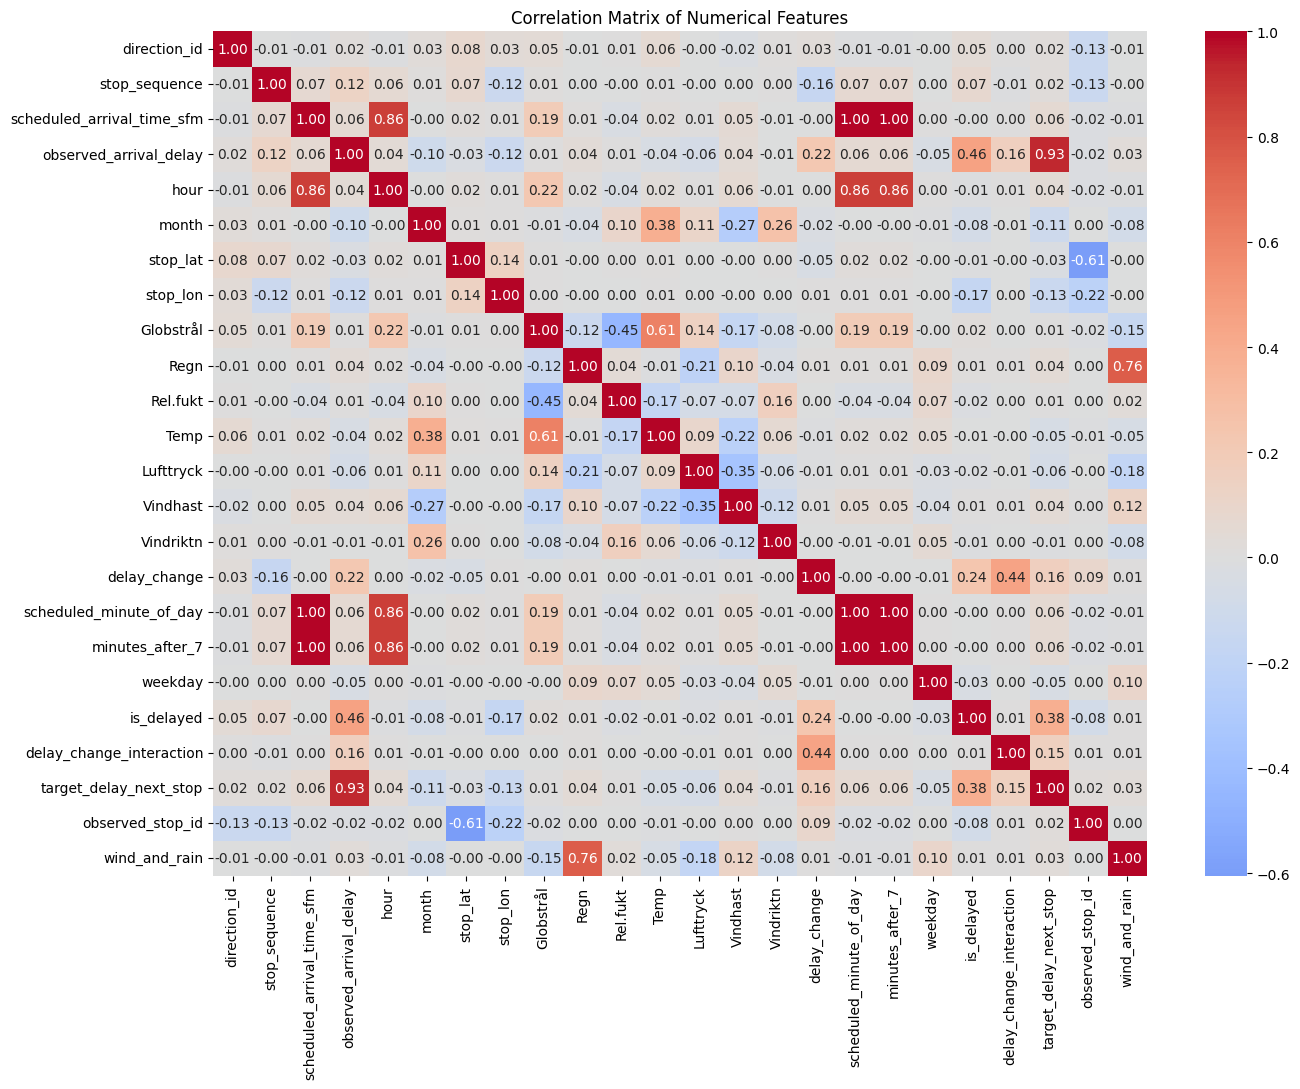

In [46]:

correlation_columns = [
    "direction_id",
    "stop_sequence",
    "scheduled_arrival_time_sfm",
    "observed_arrival_delay",
    "hour",
    "month",
    "stop_lat",
    "stop_lon",
    "Globstrål",
    "Regn",
    "Rel.fukt",
    "Temp",
    "Lufttryck",
    "Vindhast",
    "Vindriktn",
    "delay_change",
    "scheduled_minute_of_day",
    "minutes_after_7",
    "weekday",
    "is_delayed",
    "delay_change_interaction",
    "target_delay_next_stop",
    "observed_stop_id",
    "wind_and_rain"
]

correlation_matrix = (
    line4_morning_2024[correlation_columns]
    .corr()
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [47]:
display(correlation_matrix)

,direction_id,stop_sequence,scheduled_arrival_time_sfm,observed_arrival_delay,hour,month,stop_lat,stop_lon,Globstrål,Regn,...,Vindriktn,delay_change,scheduled_minute_of_day,minutes_after_7,weekday,is_delayed,delay_change_interaction,target_delay_next_stop,observed_stop_id,wind_and_rain
direction_id,1.000000,-0.007370,-0.013048,0.016998,-0.014528,0.027322,0.082952,0.034868,0.045896,-0.006676,...,0.012261,0.030494,-0.012828,-0.012828,-0.001881,0.046679,0.004069,0.016290,-0.131933,-0.005318
stop_sequence,-0.007370,1.000000,0.070830,0.124816,0.063014,0.013338,0.072446,-0.123689,0.013767,0.000350,...,0.003471,-0.159473,0.070566,0.070566,0.000560,0.073570,-0.009682,0.017799,-0.132087,-0.002437
scheduled_arrival_time_sfm,-0.013048,0.070830,1.000000,0.058982,0.864297,-0.001132,0.019022,0.008246,0.190571,0.013457,...,-0.005706,-0.002049,0.999951,0.999951,0.003809,-0.000722,0.004475,0.058138,-0.021925,-0.011424
observed_arrival_delay,0.016998,0.124816,0.058982,1.000000,0.042196,-0.103128,-0.025306,-0.122535,0.006427,0.040175,...,-0.008734,0.222118,0.058472,0.058472,-0.046488,0.455389,0.158528,0.934551,-0.021428,0.031900
hour,-0.014528,0.063014,0.864297,0.042196,1.000000,-0.000489,0.016180,0.007224,0.221041,0.015237,...,-0.005461,0.000317,0.864257,0.864257,0.003259,-0.011802,0.005650,0.041150,-0.016424,-0.013001
month,0.027322,0.013338,-0.001132,-0.103128,-0.000489,1.000000,0.013119,0.007500,-0.013716,-0.042183,...,0.263481,-0.024726,-0.001547,-0.001547,-0.012008,-0.075648,-0.005001,-0.110563,0.002322,-0.082326
stop_lat,0.082952,0.072446,0.019022,-0.025306,0.016180,0.013119,1.000000,0.136469,0.005487,-0.000565,...,0.003668,-0.045950,0.016170,0.016170,-0.000466,-0.009985,-0.001241,-0.027715,-0.605144,-0.002019
stop_lon,0.034868,-0.123689,0.008246,-0.122535,0.007224,0.007500,0.136469,1.000000,0.003418,-0.000237,...,0.003047,0.009161,0.007719,0.007719,-0.000544,-0.169846,0.000231,-0.132563,-0.221445,-0.001175
Globstrål,0.045896,0.013767,0.190571,0.006427,0.221041,-0.013716,0.005487,0.003418,1.000000,-0.123563,...,-0.083983,-0.002993,0.190624,0.190624,-0.001680,0.020404,0.001817,0.006946,-0.018571,-0.152578
Regn,-0.006676,0.000350,0.013457,0.040175,0.015237,-0.042183,-0.000565,-0.000237,-0.123563,1.000000,...,-0.037373,0.009923,0.013480,0.013480,0.090650,0.010168,0.011942,0.041473,0.000948,0.759773


We drop is_dealyed and scheduled_arrival_time_sfm & scheduled_minute_of_day as welll as hour since they are redudant

In [48]:
line4_morning_2024 = line4_morning_2024.drop(
    columns=[
        "is_delayed",
        "scheduled_arrival_time_sfm",
        "scheduled_minute_of_day",
        "hour",
        "delay_change",
        "stop_lat",
        "stop_lon"
    ]
)

we added wind and rain

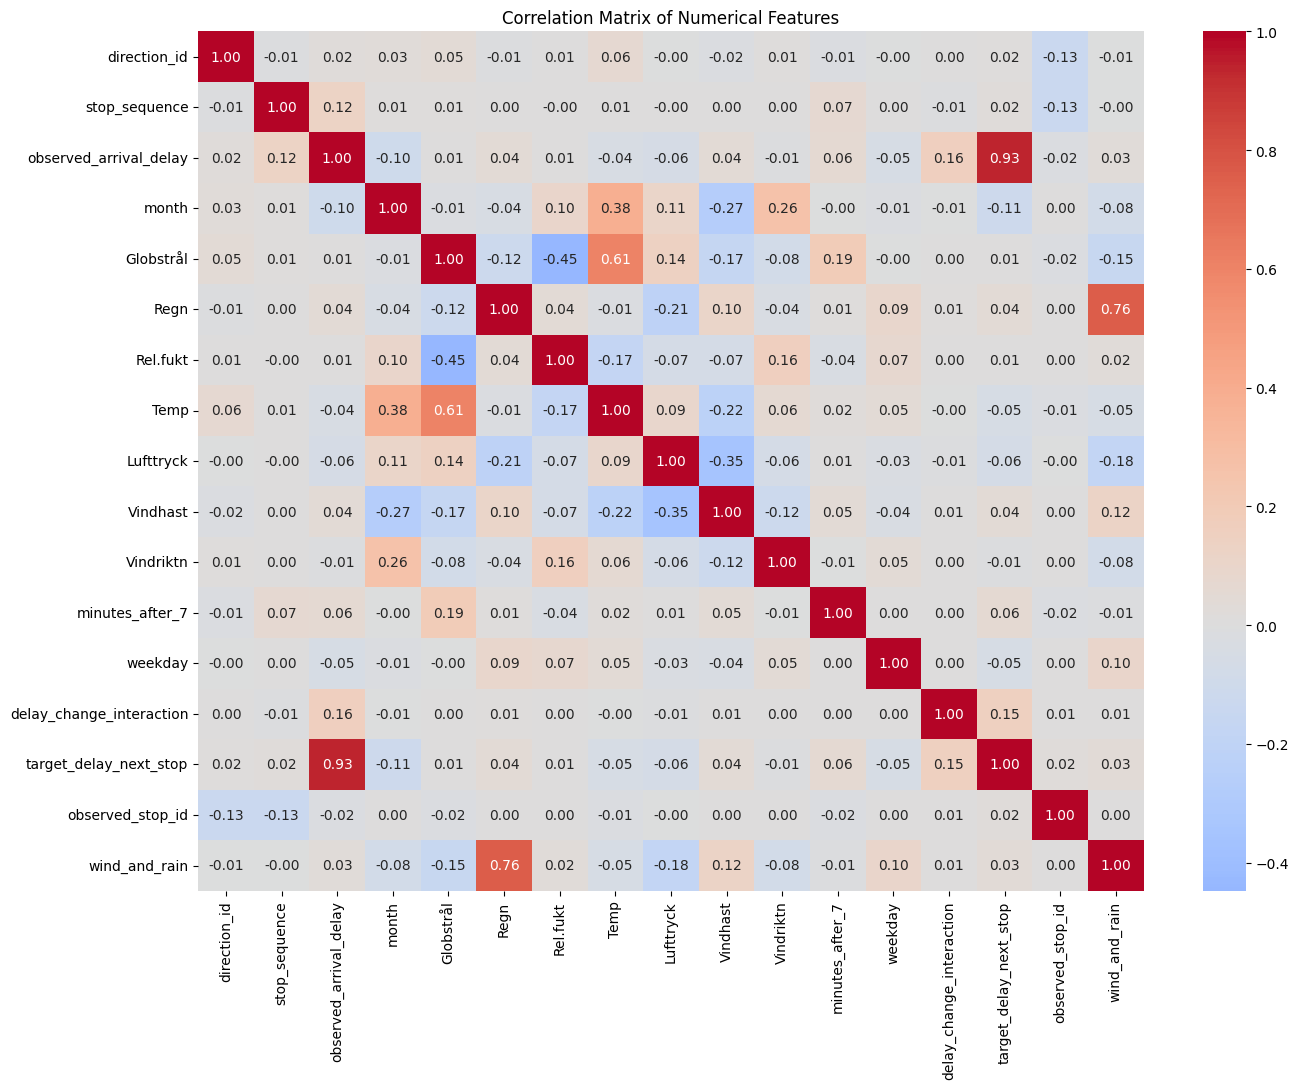

In [49]:
correlation_columns = [
    "direction_id",
    "stop_sequence",
    "observed_arrival_delay",
    "month",
    "Globstrål",
    "Regn",
    "Rel.fukt",
    "Temp",
    "Lufttryck",
    "Vindhast",
    "Vindriktn",
    "minutes_after_7",
    "weekday",
    "delay_change_interaction",
    "target_delay_next_stop",
    "observed_stop_id",
    "wind_and_rain"
]

correlation_matrix = (
    line4_morning_2024[correlation_columns]
    .corr()
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [52]:
# Remove rows with missing values in essential delay features

line4_morning_2024 = line4_morning_2024.dropna(
    subset=[
        "observed_arrival_delay",
        "delay_change_interaction"
    ]
).copy()

print("Dataset shape after removing missing delay values:")
print(line4_morning_2024.shape)

Dataset shape after removing missing delay values:
(179245, 23)


## Train/Test Split

The data is divided into training and test sets using unique dates rather than individual observations. This ensures that observations from the same day are kept in the same dataset, reducing the risk of information from the same operating day appearing in both training and test data.

In [53]:
# Define features and target

target = "target_delay_next_stop"

X = line4_morning_2024.drop(
    columns=[target]
)

y = line4_morning_2024[target]

print("Number of features:", X.shape[1])
print("Number of observations:", X.shape[0])

Number of features: 22
Number of observations: 179245


In [54]:
from sklearn.model_selection import train_test_split

# Get all unique dates
unique_dates = line4_morning_2024["date"].drop_duplicates()

# Split dates into training and test sets
train_dates, test_dates = train_test_split(
    unique_dates,
    test_size=0.20,
    random_state=42
)

# Create masks based on the selected dates
train_mask = line4_morning_2024["date"].isin(train_dates)
test_mask = line4_morning_2024["date"].isin(test_dates)

# Create training and test sets
X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nNumber of training days:", len(train_dates))
print("Number of test days:", len(test_dates))

print("\nTraining period:")
print(X_train["date"].min(), "to", X_train["date"].max())

print("\nTest period:")
print(X_test["date"].min(), "to", X_test["date"].max())

Training set: (143100, 22)
Test set: (36145, 22)

Number of training days: 205
Number of test days: 52

Training period:
2024-01-01 00:00:00 to 2024-12-31 00:00:00

Test period:
2024-01-09 00:00:00 to 2024-12-30 00:00:00


## Preprocssing

Numerical variables are median-imputed and standardized, while categorical variables are imputed using the most frequent value and one-hot encoded. The preprocessing is fitted using the training data and then applied to the test data

In [55]:
# Define columns that should not be used as model features
columns_to_drop = [
    "date",
    "route_id",
    "shape_id"
]

X_train_model = X_train.drop(columns=columns_to_drop).copy()
X_test_model = X_test.drop(columns=columns_to_drop).copy()

print("Training features:")
print(X_train_model.columns.tolist())

print("\nNumber of features before encoding:", X_train_model.shape[1])

Training features:
['direction_id', 'stop_sequence', 'observed_stop_id', 'observed_arrival_delay', 'month', 'Globstrål', 'Regn', 'Rel.fukt', 'Temp', 'Lufttryck', 'Vindhast', 'Vindriktn', 'temperature_category', 'minutes_after_7', 'weekday', 'delay_change_interaction', 'is_raining', 'cold_and_rain', 'wind_and_rain']

Number of features before encoding: 19


In [56]:
# Define numerical and categorical features

numerical_features = [
    "stop_sequence",
    "observed_arrival_delay",
    "Globstrål",
    "Regn",
    "Rel.fukt",
    "Temp",
    "Lufttryck",
    "Vindhast",
    "minutes_after_7",
    "delay_change_interaction",
    "is_raining",
    "cold_and_rain",
    "wind_and_rain"
]

categorical_features = [
    "direction_id",
    "observed_stop_id",
    "month",
    "Vindriktn",
    "temperature_category",
    "weekday"
]

print("Numerical features:", len(numerical_features))
print(numerical_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numerical features: 13
['stop_sequence', 'observed_arrival_delay', 'Globstrål', 'Regn', 'Rel.fukt', 'Temp', 'Lufttryck', 'Vindhast', 'minutes_after_7', 'delay_change_interaction', 'is_raining', 'cold_and_rain', 'wind_and_rain']

Categorical features: 6
['direction_id', 'observed_stop_id', 'month', 'Vindriktn', 'temperature_category', 'weekday']


In [57]:
# Preprocessing for numerical features
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical features
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [58]:
# Fit the preprocessing pipeline on the training data
X_train_processed = preprocessor.fit_transform(X_train_model)

# Transform the test data using the fitted pipeline
X_test_processed = preprocessor.transform(X_test_model)

print("Training data after preprocessing:", X_train_processed.shape)
print("Test data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (143100, 448)
Test data after preprocessing: (36145, 448)


# Model 1: Linear Regression

In [59]:
# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_processed, y_train)

print("Linear Regression model trained.")

Linear Regression model trained.


In [60]:
# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test_processed)

# Calculate evaluation metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression performance:")
print(f"MAE:  {mae_linear:.2f} seconds")
print(f"RMSE: {rmse_linear:.2f} seconds")
print(f"R²:   {r2_linear:.4f}")

Linear Regression performance:
MAE:  26.85 seconds
RMSE: 41.11 seconds
R²:   0.9411


# Model 1b: Optimized Linear Regression

In order to optimize the linear regression we do lasso and ridge to lessen the varibles in the line

In [61]:
# Define alpha values to test
alphas = np.logspace(-3, 3, 20)


# Ridge Regression

ridge_model = RidgeCV(
    alphas=alphas,
    cv=5
)

ridge_model.fit(X_train_processed, y_train)

y_pred_ridge = ridge_model.predict(X_test_processed)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression performance:")
print(f"Best alpha: {ridge_model.alpha_:.4f}")
print(f"MAE:  {mae_ridge:.2f} seconds")
print(f"RMSE: {rmse_ridge:.2f} seconds")
print(f"R²:   {r2_ridge:.4f}")


# Lasso Regression

lasso_model = LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=10000,
    n_jobs=-1
)

lasso_model.fit(X_train_processed, y_train)

y_pred_lasso = lasso_model.predict(X_test_processed)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\nLasso Regression performance:")
print(f"Best alpha: {lasso_model.alpha_:.4f}")
print(f"MAE:  {mae_lasso:.2f} seconds")
print(f"RMSE: {rmse_lasso:.2f} seconds")
print(f"R²:   {r2_lasso:.4f}")

Ridge Regression performance:
Best alpha: 12.7427
MAE:  22.56 seconds
RMSE: 37.47 seconds
R²:   0.9510

Lasso Regression performance:
Best alpha: 0.0183
MAE:  22.54 seconds
RMSE: 37.48 seconds
R²:   0.9510


In [62]:
# Count the number of features selected by Lasso

lasso_coefficients = lasso_model.coef_

n_total_features = len(lasso_coefficients)
n_selected_features = np.sum(lasso_coefficients != 0)
n_removed_features = n_total_features - n_selected_features

print("Lasso feature selection:")
print(f"Total features:    {n_total_features}")
print(f"Selected features: {n_selected_features}")
print(f"Removed features:  {n_removed_features}")

Lasso feature selection:
Total features:    448
Selected features: 82
Removed features:  366


In [63]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get Lasso coefficients
lasso_coefficients = lasso_model.coef_

# Create a table with feature names and coefficients
lasso_features = pd.DataFrame({
    "feature": feature_names,
    "coefficient": lasso_coefficients
})

# Keep only features selected by Lasso
selected_lasso_features = lasso_features[
    lasso_features["coefficient"] != 0
].copy()

# Sort by absolute coefficient size
selected_lasso_features["abs_coefficient"] = (
    selected_lasso_features["coefficient"].abs()
)

selected_lasso_features = selected_lasso_features.sort_values(
    "abs_coefficient",
    ascending=False
)

print(f"Number of selected features: {len(selected_lasso_features)}")
print(selected_lasso_features[["feature", "coefficient"]].to_string(index=False))

Number of selected features: 82
                               feature   coefficient
cat__observed_stop_id_9022001010261004 -2.189983e+02
           num__observed_arrival_delay  2.010343e+02
cat__observed_stop_id_9022001010369008  1.219440e+02
cat__observed_stop_id_9022001010627002 -1.173178e+02
cat__observed_stop_id_9022001010645002 -8.551841e+01
cat__observed_stop_id_9022001010645001 -8.454220e+01
cat__observed_stop_id_9022001010649002  7.833340e+01
cat__observed_stop_id_9022001010369001  7.153874e+01
cat__observed_stop_id_9022001010198002 -6.285036e+01
cat__observed_stop_id_9022001010151002  5.181709e+01
cat__observed_stop_id_9022001010199001 -5.026348e+01
cat__observed_stop_id_9022001010151003  4.880833e+01
cat__observed_stop_id_9022001010188001 -4.280533e+01
cat__observed_stop_id_9022001010649001  3.687168e+01
cat__observed_stop_id_9022001010193001 -3.577232e+01
cat__observed_stop_id_9022001010657001 -3.571761e+01
cat__observed_stop_id_9022001010655001  3.404164e+01
cat__observed_

# Model 2: XGBoost

In [64]:
# Create the XGBoost regression model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_model.fit(X_train_processed, y_train)

print("XGBoost model trained.")

XGBoost model trained.


In [65]:
# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_processed)

# Calculate evaluation metrics
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost performance:")
print(f"MAE:  {mae_xgb:.2f} seconds")
print(f"RMSE: {rmse_xgb:.2f} seconds")
print(f"R²:   {r2_xgb:.4f}")

XGBoost performance:
MAE:  21.78 seconds
RMSE: 47.08 seconds
R²:   0.9227


# Model 2b: XGBoost Optimizing

In [ ]:
# Base XGBoost model
xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Hyperparameter search space
xgb_param_grid = {
    "n_estimators": [200, 400, 600, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

# Randomized hyperparameter search
xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Run the search
xgb_search.fit(X_train_processed, y_train)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("\nBest cross-validation RMSE:")
print(f"{-xgb_search.best_score_:.2f} seconds")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGBoost parameters:
{'subsample': 1.0, 'n_estimators': 600, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Best cross-validation RMSE:
107.25 seconds


In [66]:
# Train optimized XGBoost model
xgb_optimized = XGBRegressor(
    n_estimators=600,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=10,
    subsample=1.0,
    colsample_bytree=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_optimized.fit(X_train_processed, y_train)

# Predict on the untouched test set
y_pred_xgb_optimized = xgb_optimized.predict(X_test_processed)

# Evaluate model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb_optimized)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb_optimized))
r2_xgb = r2_score(y_test, y_pred_xgb_optimized)

print("Optimized XGBoost results:")
print(f"MAE:  {mae_xgb:.2f} seconds")
print(f"RMSE: {rmse_xgb:.2f} seconds")
print(f"R²:   {r2_xgb:.4f}")

Optimized XGBoost results:
MAE:  21.25 seconds
RMSE: 45.87 seconds
R²:   0.9266


# Model 3: Random Forest

In [67]:
# Create the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_processed, y_train)

RandomForestRegressor(max_depth=25, max_features='sqrt', min_samples_leaf=3,
                      n_estimators=300, n_jobs=-1, random_state=42)

In [68]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_processed)

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest performance:")
print(f"MAE:  {mae_rf:.2f} seconds")
print(f"RMSE: {rmse_rf:.2f} seconds")
print(f"R²:   {r2_rf:.4f}")

Random Forest performance:
MAE:  56.34 seconds
RMSE: 93.48 seconds
R²:   0.6953


# Model 3b: Oprimized Random Forest

In [ ]:
rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [10, 15, 20],
    "min_samples_leaf": [3, 5, 10],
    "max_features": ["sqrt", 0.3]
}

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=8,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_train_processed, y_train)

print("Best Random Forest parameters:")
print(rf_search.best_params_)

print("\nBest cross-validation RMSE:")
print(f"{-rf_search.best_score_:.2f} seconds")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Random Forest parameters:
{'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 0.3, 'max_depth': 20}

Best cross-validation RMSE:
70.67 seconds


In [69]:
# Train optimized Random Forest
rf_optimized = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    max_features=0.3,
    random_state=42,
    n_jobs=-1
)

rf_optimized.fit(X_train_processed, y_train)

# Predict on the untouched test set
y_pred_rf_optimized = rf_optimized.predict(X_test_processed)

# Evaluate model
mae_rf = mean_absolute_error(y_test, y_pred_rf_optimized)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_optimized))
r2_rf = r2_score(y_test, y_pred_rf_optimized)

print("Optimized Random Forest results:")
print(f"MAE:  {mae_rf:.2f} seconds")
print(f"RMSE: {rmse_rf:.2f} seconds")
print(f"R²:   {r2_rf:.4f}")

Optimized Random Forest results:
MAE:  23.71 seconds
RMSE: 39.50 seconds
R²:   0.9456


# comparing all the models

In [70]:
# this code if all have been run this session
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "XGBoost",
        "Random Forest"
    ],
    "MAE (s)": [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_xgb_optimized),
        mean_absolute_error(y_test, y_pred_rf_optimized)
    ],
    "RMSE (s)": [
        np.sqrt(mean_squared_error(y_test, y_pred_linear)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb_optimized)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf_optimized))
    ],
    "R²": [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_xgb_optimized),
        r2_score(y_test, y_pred_rf_optimized)
    ]
})

model_results

,Model,MAE (s),RMSE (s),R²
0,Linear Regression,26.852844,41.111644,0.941061
1,Ridge,22.556463,37.471334,0.951037
2,Lasso,22.537375,37.482372,0.951008
3,XGBoost,21.247337,45.873209,0.926618
4,Random Forest,23.713721,39.495008,0.945606


In [71]:
# this cell if not

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "XGBoost",
        "Random Forest"
    ],
    "MAE (s)": [
        26.85,
        22.56,
        22.54,
        21.25,
        23.71
    ],
    "RMSE (s)": [
        41.11,
        37.47,
        37.48,
        45.87,
        39.50
    ],
    "R²": [
        0.9411,
        0.9510,
        0.9510,
        0.9266,
        0.9456
    ]
})

model_results

,Model,MAE (s),RMSE (s),R²
0,Linear Regression,26.85,41.11,0.9411
1,Ridge,22.56,37.47,0.9510
2,Lasso,22.54,37.48,0.9510
3,XGBoost,21.25,45.87,0.9266
4,Random Forest,23.71,39.50,0.9456


In [72]:
# Generate predictions for all models on the held-out test set

y_pred_linear = linear_model.predict(X_test_processed)
y_pred_ridge = ridge_model.predict(X_test_processed)
y_pred_lasso = lasso_model.predict(X_test_processed)
y_pred_xgb_optimized = xgb_optimized.predict(X_test_processed)
y_pred_rf_optimized = rf_optimized.predict(X_test_processed)

print("Predictions generated for all five models.")

Predictions generated for all five models.


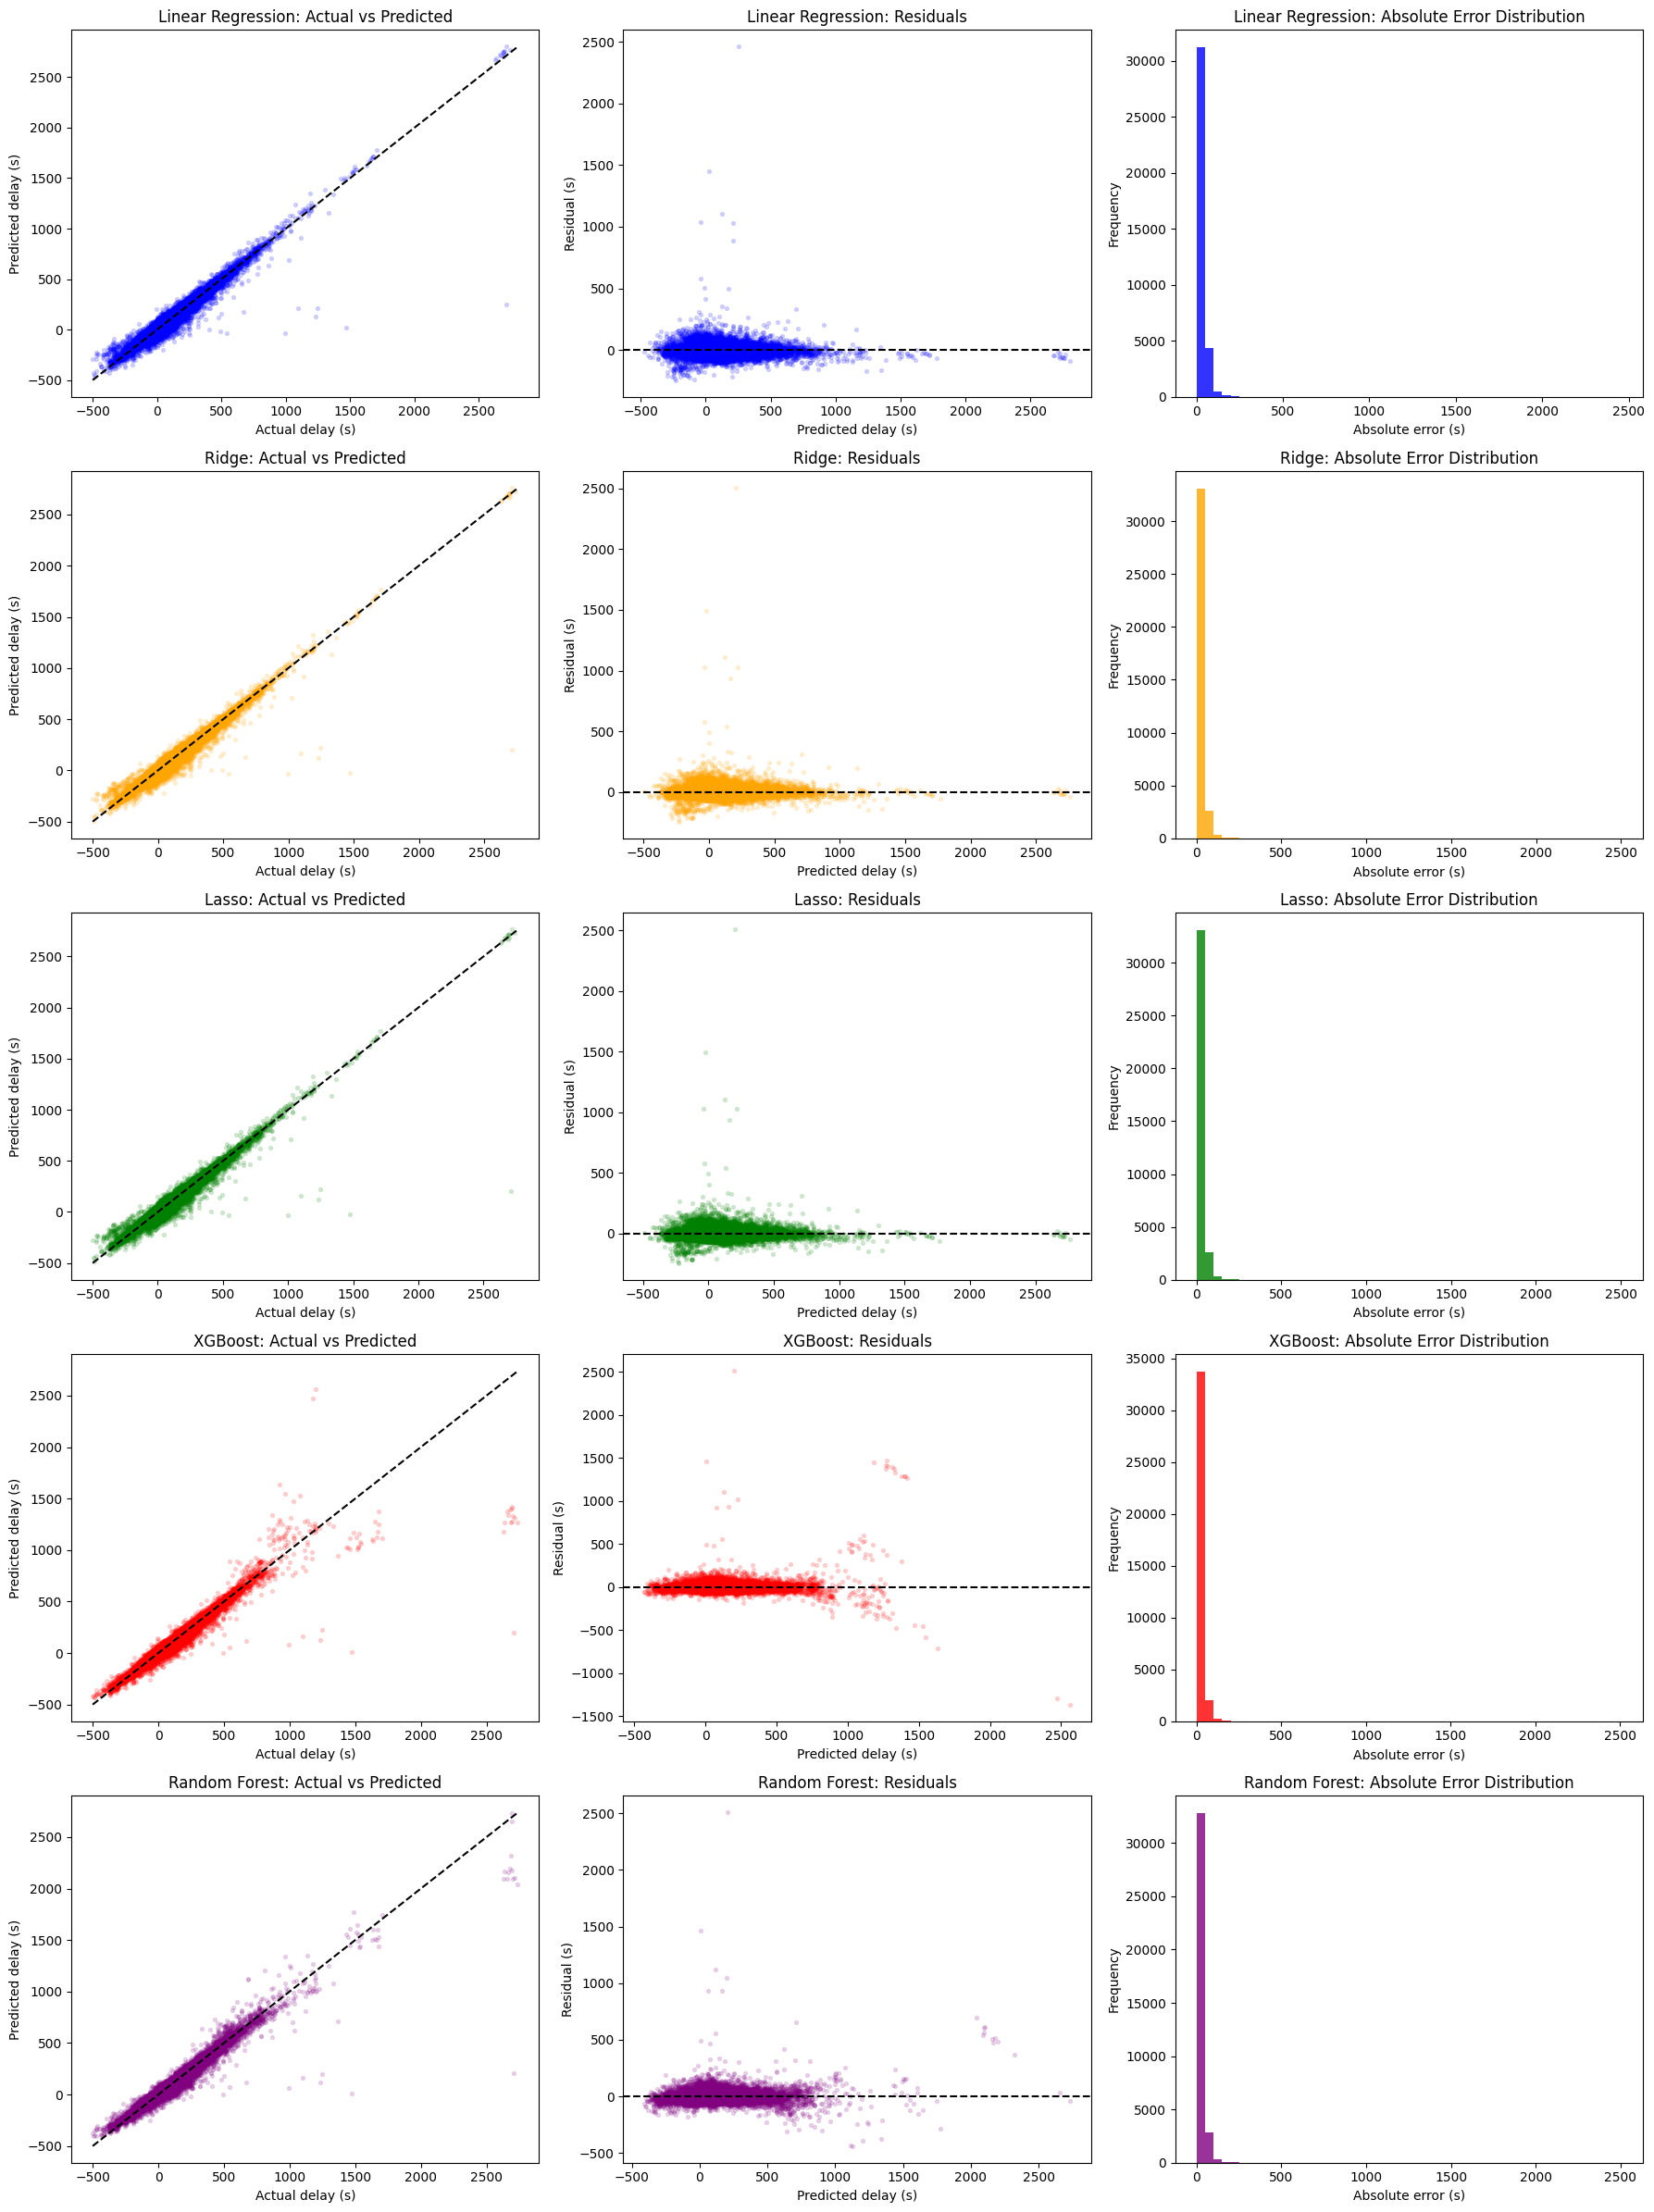

In [73]:
models = {
    "Linear Regression": y_pred_linear,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "XGBoost": y_pred_xgb_optimized,
    "Random Forest": y_pred_rf_optimized
}

model_colors = {
    "Linear Regression": "blue",
    "Ridge": "orange",
    "Lasso": "green",
    "XGBoost": "red",
    "Random Forest": "purple"
}

fig, axes = plt.subplots(
    nrows=5,
    ncols=3,
    figsize=(18, 24)
)

for row, (model_name, y_pred) in enumerate(models.items()):

    color = model_colors[model_name]

    residuals = y_test.values - y_pred
    absolute_errors = np.abs(residuals)

    # 1. Actual vs Predicted
    axes[row, 0].scatter(
        y_test,
        y_pred,
        alpha=0.15,
        s=8,
        color=color
    )

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    axes[row, 0].plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        color="black"
    )

    axes[row, 0].set_title(f"{model_name}: Actual vs Predicted")
    axes[row, 0].set_xlabel("Actual delay (s)")
    axes[row, 0].set_ylabel("Predicted delay (s)")

    # 2. Residuals vs Predicted
    axes[row, 1].scatter(
        y_pred,
        residuals,
        alpha=0.15,
        s=8,
        color=color
    )

    axes[row, 1].axhline(
        0,
        linestyle="--",
        color="black"
    )

    axes[row, 1].set_title(f"{model_name}: Residuals")
    axes[row, 1].set_xlabel("Predicted delay (s)")
    axes[row, 1].set_ylabel("Residual (s)")

    # 3. Absolute Error Distribution
    axes[row, 2].hist(
        absolute_errors,
        bins=50,
        color=color,
        alpha=0.8
    )

    axes[row, 2].set_title(f"{model_name}: Absolute Error Distribution")
    axes[row, 2].set_xlabel("Absolute error (s)")
    axes[row, 2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Diagnostics

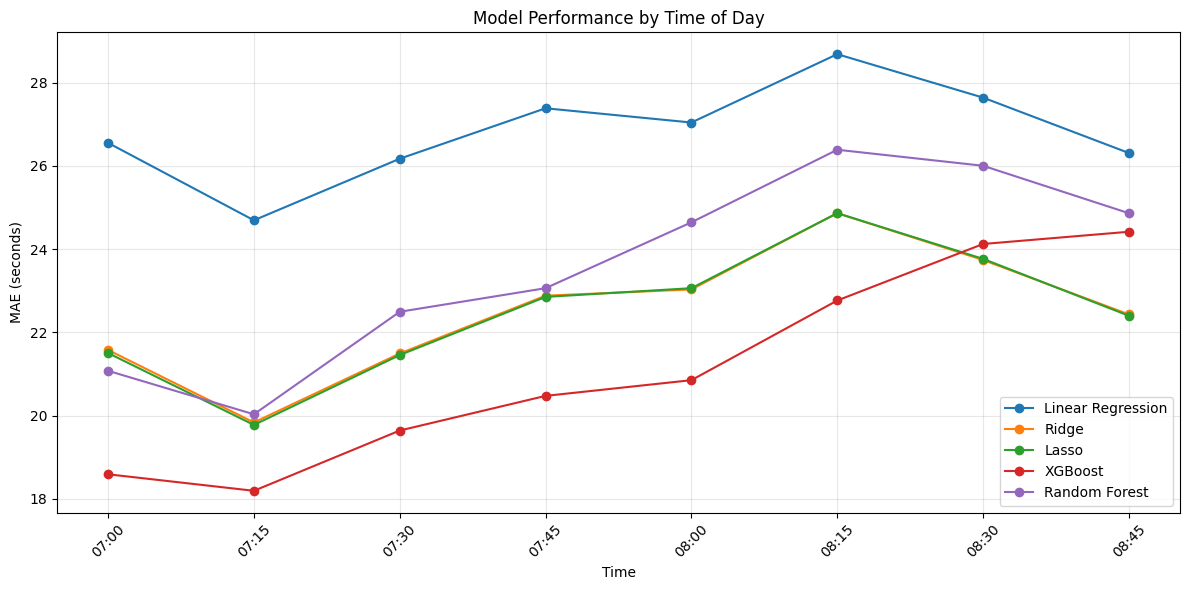

In [74]:
# Create a copy of the test data
diagnostics_time = X_test.copy()

# Add actual target and predictions
diagnostics_time["actual"] = y_test.values
diagnostics_time["Linear Regression"] = y_pred_linear
diagnostics_time["Ridge"] = y_pred_ridge
diagnostics_time["Lasso"] = y_pred_lasso
diagnostics_time["XGBoost"] = y_pred_xgb_optimized
diagnostics_time["Random Forest"] = y_pred_rf_optimized

# Convert minutes after 07:00 into 15-minute time intervals
diagnostics_time["time_interval"] = (
    (diagnostics_time["minutes_after_7"] // 15) * 15
)

diagnostics_time["time_label"] = diagnostics_time["time_interval"].apply(
    lambda x: f"{int(7 + x // 60):02d}:{int(x % 60):02d}"
)

models = [
    "Linear Regression",
    "Ridge",
    "Lasso",
    "XGBoost",
    "Random Forest"
]

# Calculate MAE for each model and time interval
mae_by_time = []

for time_interval, group in diagnostics_time.groupby("time_interval"):

    for model in models:

        mae = np.mean(
            np.abs(group["actual"] - group[model])
        )

        mae_by_time.append({
            "time_interval": time_interval,
            "time_label": group["time_label"].iloc[0],
            "Model": model,
            "MAE": mae
        })

mae_by_time = pd.DataFrame(mae_by_time)

# Plot
plt.figure(figsize=(12, 6))

for model in models:

    model_data = mae_by_time[
        mae_by_time["Model"] == model
    ]

    plt.plot(
        model_data["time_label"],
        model_data["MAE"],
        marker="o",
        label=model
    )

plt.xlabel("Time")
plt.ylabel("MAE (seconds)")
plt.title("Model Performance by Time of Day")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

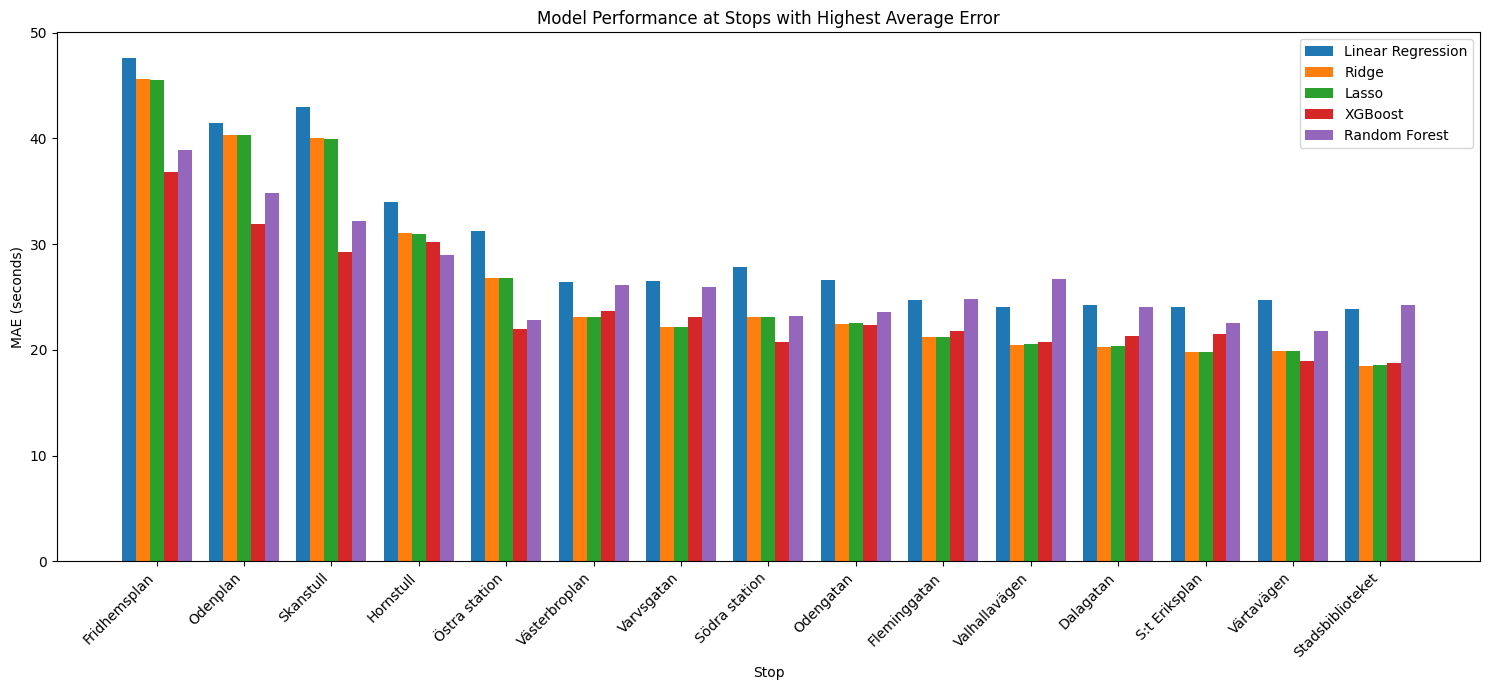

In [75]:
# Load stop names from the static GTFS stops file

stops = pd.read_csv(
    f"{project_path}/stops.csv",
    sep=";"
)

# Keep only the columns needed for the mapping
stop_name_mapping = stops[
    ["stop_id", "stop_name"]
].drop_duplicates()

# Convert IDs to the same type
stop_name_mapping["stop_id"] = stop_name_mapping["stop_id"].astype(str)
X_test_stop = X_test.copy()
X_test_stop["observed_stop_id"] = X_test_stop["observed_stop_id"].astype(str)

# Add stop names
diagnostics_stop = X_test_stop.merge(
    stop_name_mapping,
    left_on="observed_stop_id",
    right_on="stop_id",
    how="left"
)

# Add actual values and predictions
diagnostics_stop["actual"] = y_test.values
diagnostics_stop["Linear Regression"] = y_pred_linear
diagnostics_stop["Ridge"] = y_pred_ridge
diagnostics_stop["Lasso"] = y_pred_lasso
diagnostics_stop["XGBoost"] = y_pred_xgb_optimized
diagnostics_stop["Random Forest"] = y_pred_rf_optimized

models = [
    "Linear Regression",
    "Ridge",
    "Lasso",
    "XGBoost",
    "Random Forest"
]

# Calculate MAE by stop
mae_by_stop = []

for stop_name, group in diagnostics_stop.groupby("stop_name"):

    row = {
        "stop_name": stop_name,
        "n_observations": len(group)
    }

    for model in models:
        row[model] = np.mean(
            np.abs(group["actual"] - group[model])
        )

    mae_by_stop.append(row)

mae_by_stop = pd.DataFrame(mae_by_stop)

# Average MAE across all models
mae_by_stop["mean_mae"] = mae_by_stop[models].mean(axis=1)

# Select 15 stops with highest average error
top_problem_stops = (
    mae_by_stop
    .sort_values("mean_mae", ascending=False)
    .head(15)
)

# Plot
plt.figure(figsize=(15, 7))

x = np.arange(len(top_problem_stops))
width = 0.16

for i, model in enumerate(models):
    plt.bar(
        x + i * width,
        top_problem_stops[model],
        width,
        label=model
    )

plt.xlabel("Stop")
plt.ylabel("MAE (seconds)")
plt.title("Model Performance at Stops with Highest Average Error")

plt.xticks(
    x + width * 2,
    top_problem_stops["stop_name"],
    rotation=45,
    ha="right"
)

plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_578/3164199962.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for month, group in diagnostics_month.groupby("month"):


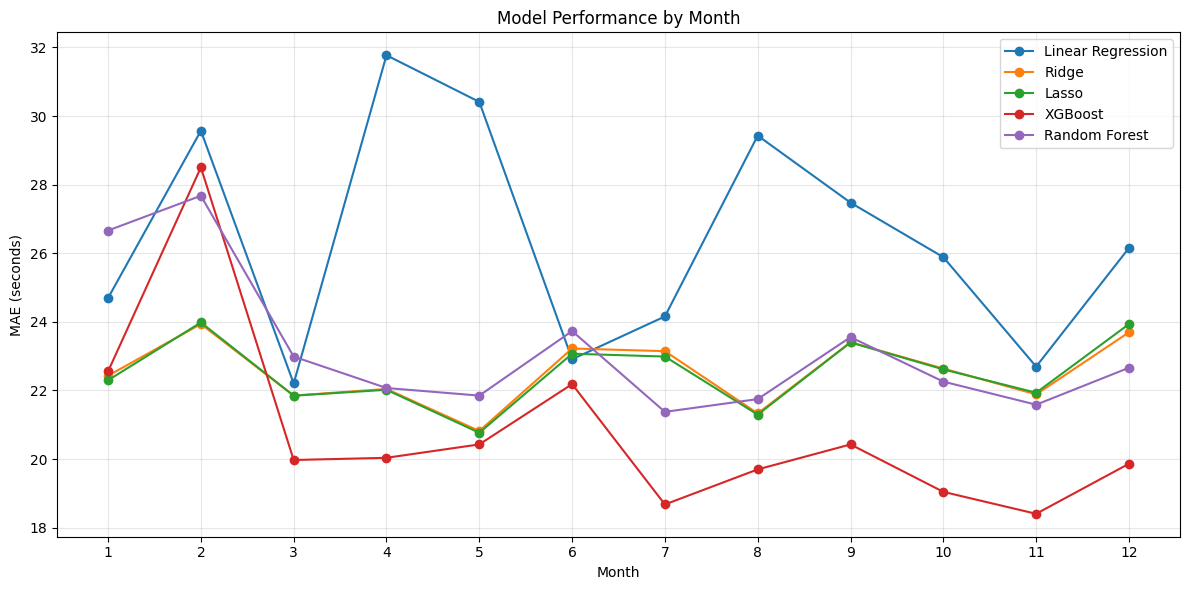

In [76]:
# Calculate MAE by month for all models

diagnostics_month = X_test.copy()

diagnostics_month["actual"] = y_test.values
diagnostics_month["Linear Regression"] = y_pred_linear
diagnostics_month["Ridge"] = y_pred_ridge
diagnostics_month["Lasso"] = y_pred_lasso
diagnostics_month["XGBoost"] = y_pred_xgb_optimized
diagnostics_month["Random Forest"] = y_pred_rf_optimized

models = [
    "Linear Regression",
    "Ridge",
    "Lasso",
    "XGBoost",
    "Random Forest"
]

mae_by_month = []

for month, group in diagnostics_month.groupby("month"):

    row = {
        "month": month,
        "n_observations": len(group)
    }

    for model in models:
        row[model] = np.mean(
            np.abs(group["actual"] - group[model])
        )

    mae_by_month.append(row)

mae_by_month = pd.DataFrame(mae_by_month)

# Sort months chronologically
mae_by_month = mae_by_month.sort_values("month")

# Plot
plt.figure(figsize=(12, 6))

for model in models:

    plt.plot(
        mae_by_month["month"].astype(str),
        mae_by_month[model],
        marker="o",
        label=model
    )

plt.xlabel("Month")
plt.ylabel("MAE (seconds)")
plt.title("Model Performance by Month")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

,delay_category,n_observations,Linear Regression,Ridge,Lasso,XGBoost,Random Forest
0,< 60 s,19457,25.665874,21.172574,21.141246,17.757209,20.317730
1,60–120 s,6146,25.574712,21.100465,21.077456,19.049322,21.926875
2,120–300 s,7649,27.620356,23.837578,23.845049,22.169778,25.556466
3,> 300 s,2893,35.521899,31.569813,31.571167,46.950989,45.477499


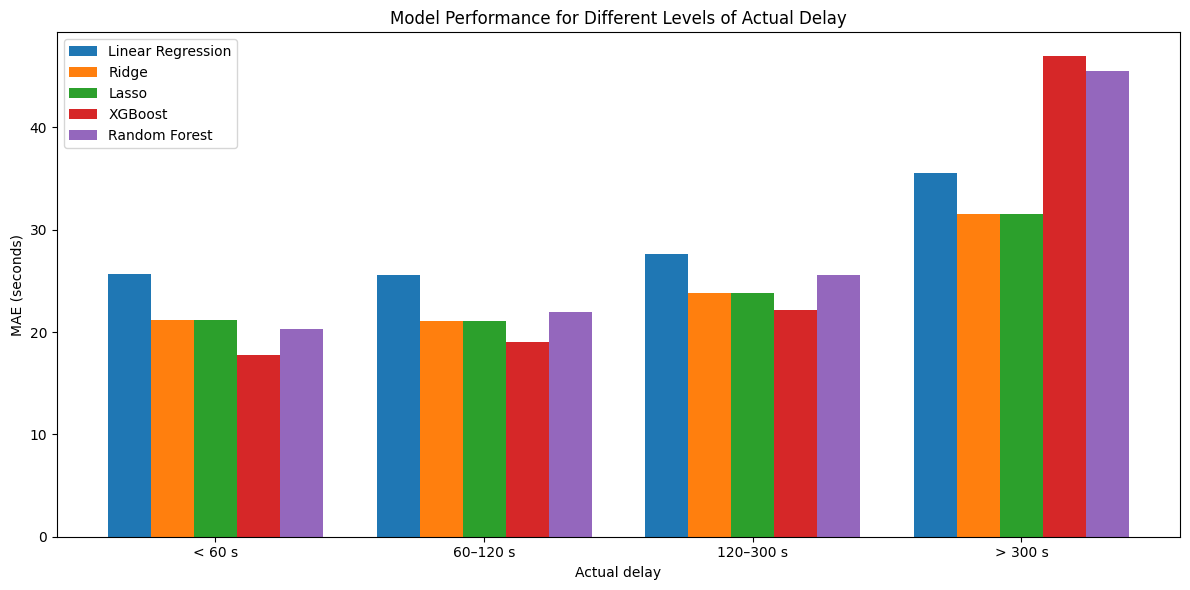

In [77]:
# Analyze model performance for different levels of actual delay

diagnostics_delay = pd.DataFrame({
    "actual": y_test.values,
    "Linear Regression": y_pred_linear,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "XGBoost": y_pred_xgb_optimized,
    "Random Forest": y_pred_rf_optimized
})

# Define delay categories
diagnostics_delay["delay_category"] = pd.cut(
    diagnostics_delay["actual"],
    bins=[-np.inf, 60, 120, 300, np.inf],
    labels=[
        "< 60 s",
        "60–120 s",
        "120–300 s",
        "> 300 s"
    ]
)

models = [
    "Linear Regression",
    "Ridge",
    "Lasso",
    "XGBoost",
    "Random Forest"
]

mae_by_delay = []

for category, group in diagnostics_delay.groupby(
    "delay_category",
    observed=False
):

    row = {
        "delay_category": category,
        "n_observations": len(group)
    }

    for model in models:
        row[model] = np.mean(
            np.abs(group["actual"] - group[model])
        )

    mae_by_delay.append(row)

mae_by_delay = pd.DataFrame(mae_by_delay)

# Display the results
display(mae_by_delay)

# Plot
plt.figure(figsize=(12, 6))

x = np.arange(len(mae_by_delay))
width = 0.16

for i, model in enumerate(models):
    plt.bar(
        x + i * width,
        mae_by_delay[model],
        width,
        label=model
    )

plt.xlabel("Actual delay")
plt.ylabel("MAE (seconds)")
plt.title("Model Performance for Different Levels of Actual Delay")

plt.xticks(
    x + width * 2,
    mae_by_delay["delay_category"]
)

plt.legend()
plt.tight_layout()
plt.show()

In [78]:
# Weather data missingness analysis

weather_cols = [
    "Globstrål",
    "Regn",
    "Rel.fukt",
    "Temp",
    "Lufttryck",
    "Vindhast",
    "Vindriktn"
]

# Identify observations with at least one missing weather value
weather_missing = X_test_model[weather_cols].isna().any(axis=1)

# Calculate MAE for observations with complete vs missing weather data
missing_results = []

models = {
    "Linear Regression": y_pred_linear,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "XGBoost": y_pred_xgb_optimized,
    "Random Forest": y_pred_rf_optimized
}

for model_name, predictions in models.items():
    mae_complete = mean_absolute_error(
        y_test[~weather_missing],
        predictions[~weather_missing]
    )

    mae_missing = mean_absolute_error(
        y_test[weather_missing],
        predictions[weather_missing]
    )

    missing_results.append({
        "Model": model_name,
        "Complete weather data": mae_complete,
        "Missing weather data": mae_missing
    })

missing_results_df = pd.DataFrame(missing_results)

print(missing_results_df.round(2))
print(f"\nObservations with complete weather data: {(~weather_missing).sum()}")
print(f"Observations with missing weather data: {weather_missing.sum()}")

               Model  Complete weather data  Missing weather data
0  Linear Regression                  26.46                 31.88
1              Ridge                  22.54                 22.72
2              Lasso                  22.53                 22.68
3            XGBoost                  21.30                 20.53
4      Random Forest                  23.80                 22.65

Observations with complete weather data: 33530
Observations with missing weather data: 2615


Missing weather data did not affect model performance (similar MAE), showing that the models are robust to missing observations.


# Things we looked at after feedback

To further investigate the model performance and address potential limitations identified during the analysis, we conducted several additional diagnostic and sensitivity analyses. These analyses examine how model performance varies under different conditions and how dependent the predictions are on specific input variables.

## Delay sensitivity

Ridge, XGBoost and Random Forest were selected because they represent both linear and non-linear modelling approaches and performed well in the main analysis. We use them to investigate how much the model performance depends on the current observed delay as well as weather.

In [79]:
# Sensitivity analysis: remove current delay information

sensitivity_drop = [
    "observed_arrival_delay",
    "delay_change_interaction"
]

X_train_sensitivity = X_train_model.drop(
    columns=sensitivity_drop
).copy()

X_test_sensitivity = X_test_model.drop(
    columns=sensitivity_drop
).copy()

numerical_features_sensitivity = [
    "stop_sequence",
    "Globstrål",
    "Regn",
    "Rel.fukt",
    "Temp",
    "Lufttryck",
    "Vindhast",
    "minutes_after_7",
    "is_raining",
    "cold_and_rain",
    "wind_and_rain"
]

categorical_features_sensitivity = [
    "direction_id",
    "observed_stop_id",
    "month",
    "Vindriktn",
    "temperature_category",
    "weekday"
]

numerical_pipeline_sensitivity = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_sensitivity = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_sensitivity = ColumnTransformer([
    ("num", numerical_pipeline_sensitivity, numerical_features_sensitivity),
    ("cat", categorical_pipeline_sensitivity, categorical_features_sensitivity)
])

X_train_sensitivity_processed = preprocessor_sensitivity.fit_transform(
    X_train_sensitivity
)

X_test_sensitivity_processed = preprocessor_sensitivity.transform(
    X_test_sensitivity
)

print("Training shape:", X_train_sensitivity_processed.shape)
print("Test shape:", X_test_sensitivity_processed.shape)

Training shape: (143100, 446)
Test shape: (36145, 446)


In [82]:
# Ridge
ridge_sensitivity = Ridge(
    alpha=12.7427
)

ridge_sensitivity.fit(
    X_train_sensitivity_processed,
    y_train
)

pred_ridge_sensitivity = ridge_sensitivity.predict(
    X_test_sensitivity_processed
)


# XGBoost
xgb_sensitivity = XGBRegressor(
    n_estimators=600,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=10,
    subsample=1.0,
    colsample_bytree=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_sensitivity.fit(
    X_train_sensitivity_processed,
    y_train
)

pred_xgb_sensitivity = xgb_sensitivity.predict(
    X_test_sensitivity_processed
)


# Random Forest
rf_sensitivity = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    max_features=0.3,
    random_state=42,
    n_jobs=-1
)

rf_sensitivity.fit(
    X_train_sensitivity_processed,
    y_train
)

pred_rf_sensitivity = rf_sensitivity.predict(
    X_test_sensitivity_processed
)

In [83]:
sensitivity_results = []

sensitivity_models = {
    "Ridge": pred_ridge_sensitivity,
    "XGBoost": pred_xgb_sensitivity,
    "Random Forest": pred_rf_sensitivity
}

for model_name, predictions in sensitivity_models.items():

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    sensitivity_results.append({
        "Model": model_name,
        "MAE without current delay (s)": mae,
        "RMSE without current delay (s)": rmse,
        "R² without current delay": r2
    })

sensitivity_results_df = pd.DataFrame(sensitivity_results)

print(sensitivity_results_df.round(3).to_string(index=False))

        Model  MAE without current delay (s)  RMSE without current delay (s)  R² without current delay
        Ridge                        108.560                         161.664                     0.089
      XGBoost                        103.795                         155.452                     0.157
Random Forest                        102.772                         155.823                     0.153


## Weather Sensitivity

In [84]:
# Sensitivity analysis: impact of weather variables

weather_features = [
    "Globstrål",
    "Regn",
    "Rel.fukt",
    "Temp",
    "Lufttryck",
    "Vindhast",
    "Vindriktn",
    "temperature_category",
    "is_raining",
    "cold_and_rain",
    "wind_and_rain"
]

# Remove weather features from train and test data
X_train_no_weather = X_train_model.drop(
    columns=weather_features
).copy()

X_test_no_weather = X_test_model.drop(
    columns=weather_features
).copy()

# Remaining numerical features
numerical_features_no_weather = [
    "stop_sequence",
    "minutes_after_7",
    "observed_arrival_delay",
    "delay_change_interaction"
]

# Remaining categorical features
categorical_features_no_weather = [
    "direction_id",
    "observed_stop_id",
    "month",
    "weekday"
]

# Preprocessing
numerical_pipeline_no_weather = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_no_weather = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_no_weather = ColumnTransformer([
    ("num", numerical_pipeline_no_weather, numerical_features_no_weather),
    ("cat", categorical_pipeline_no_weather, categorical_features_no_weather)
])

X_train_no_weather_processed = preprocessor_no_weather.fit_transform(
    X_train_no_weather
)

X_test_no_weather_processed = preprocessor_no_weather.transform(
    X_test_no_weather
)

print("Training shape:", X_train_no_weather_processed.shape)
print("Test shape:", X_test_no_weather_processed.shape)

Training shape: (143100, 69)
Test shape: (36145, 69)


In [85]:
# Train models without weather variables

ridge_no_weather = Ridge(
    alpha=12.7427
)

ridge_no_weather.fit(
    X_train_no_weather_processed,
    y_train
)

pred_ridge_no_weather = ridge_no_weather.predict(
    X_test_no_weather_processed
)


xgb_no_weather = XGBRegressor(
    n_estimators=600,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=10,
    subsample=1.0,
    colsample_bytree=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_no_weather.fit(
    X_train_no_weather_processed,
    y_train
)

pred_xgb_no_weather = xgb_no_weather.predict(
    X_test_no_weather_processed
)


rf_no_weather = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    max_features=0.3,
    random_state=42,
    n_jobs=-1
)

rf_no_weather.fit(
    X_train_no_weather_processed,
    y_train
)

pred_rf_no_weather = rf_no_weather.predict(
    X_test_no_weather_processed
)

In [87]:
# Compare performance with and without weather

weather_results = []

models_weather = {
    "Ridge": (y_pred_ridge, pred_ridge_no_weather),
    "XGBoost": (y_pred_xgb_optimized, pred_xgb_no_weather),
    "Random Forest": (y_pred_rf_optimized, pred_rf_no_weather)
}

for model_name, (pred_with, pred_without) in models_weather.items():

    mae_with = mean_absolute_error(y_test, pred_with)
    mae_without = mean_absolute_error(y_test, pred_without)

    rmse_with = np.sqrt(mean_squared_error(y_test, pred_with))
    rmse_without = np.sqrt(mean_squared_error(y_test, pred_without))

    weather_results.append({
        "Model": model_name,
        "MAE with weather": mae_with,
        "MAE without weather": mae_without,
        "MAE increase (s)": mae_without - mae_with,
        "RMSE with weather": rmse_with,
        "RMSE without weather": rmse_without,
        "RMSE increase (s)": rmse_without - rmse_with
    })

weather_results_df = pd.DataFrame(weather_results)

print(
    weather_results_df.round(2).to_string(index=False)
)

        Model  MAE with weather  MAE without weather  MAE increase (s)  RMSE with weather  RMSE without weather  RMSE increase (s)
        Ridge             22.56                22.53             -0.03              37.47                 37.47              -0.00
      XGBoost             21.25                25.02              3.77              45.87                158.86             112.99
Random Forest             23.71                23.41             -0.30              39.50                 40.50               1.00
